In [22]:
import pandas as pd
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt



## Jaccard Similarity

In [3]:
df_matrix = pd.read_csv('investor_category_temporal_matrix.csv')
df_main = pd.read_csv('investor_startup.csv')

C:\Users\wsswi\AppData\Local\Temp\ipykernel_20196\1779998922.py:2: DtypeWarning: Columns (31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_main = pd.read_csv('investor_startup.csv')


In [4]:
def weighted_jaccard_similarity(investor1, investor2, year):
    investor1 = df_matrix.loc[(df_matrix['year'] == year) & (df_matrix['investor_uuid'] == investor1)].drop(['investor_uuid', 'year'], axis=1)
    investor2 = df_matrix.loc[(df_matrix['year'] == year) & (df_matrix['investor_uuid'] == investor2)].drop(['investor_uuid', 'year'], axis=1)
    # get min sum
    min_sum = float(investor1.min().combine(investor2.min(), min).sum())
    # get max sum
    max_sum = float(investor1.max().combine(investor2.max(), max).sum())
    if max_sum == 0:
        wjs = 0
    else:
        wjs = min_sum/max_sum
    return wjs


In [5]:
weighted_jaccard_similarity('62e52e7d-5d37-4daa-8973-5b3c23a78f0a','64899e0b-6714-a4c8-08c3-bd240b8bf5a7',1919)


0.07692307692307691

In [8]:
rivalry_score=[]
df_main['announced_on'] = pd.to_datetime(df_main['announced_on'])
df_main['year'] = df_main['announced_on'].dt.year

years = df_main['year'].unique()
df_main['category_region'] = df_main['category_groups_list'] + df_main['org_region']
for year in years:
    df_year = df_main[df_main['year'] == year]
    investors = df_year['investor_uuid'].unique()
    category_region = df_year['category_region'].unique()
    for category_region in category_region:
        df_cr = df_year[df_year['category_region'] == category_region]
        investors = df_cr['investor_uuid'].unique()
        for investor1, investor2 in combinations(investors, 2):
            wjs = weighted_jaccard_similarity(investor1, investor2, year)
            rivalry_score.append([year, investor1, investor2, wjs])

df_rs = pd.DataFrame(rivalry_score, columns=['year', 'investor1', 'investor2', 'rivalry_score'])
df_rs


,year,investor1,investor2,rivalry_score
0,2005,b08efc27-da40-505a-6f9d-c9e14247bf36,6bbee73e-72ca-be5f-9cd2-ddc54a8b237f,0.101639
1,2005,b08efc27-da40-505a-6f9d-c9e14247bf36,0159561f-be5d-81eb-7ccd-b4d6efeb30fc,0.037037
2,2005,b08efc27-da40-505a-6f9d-c9e14247bf36,cbf72215-6a1c-f4ef-e17f-0a958eca3dac,0.037037
3,2005,b08efc27-da40-505a-6f9d-c9e14247bf36,b17358c5-2334-a1fc-1024-8a741e35f8bc,0.109725
4,2005,6bbee73e-72ca-be5f-9cd2-ddc54a8b237f,0159561f-be5d-81eb-7ccd-b4d6efeb30fc,0.333333
...,...,...,...,...
2672406,1919,62e52e7d-5d37-4daa-8973-5b3c23a78f0a,141b247f-dede-40bc-ad6b-e2d14d2fb13a,1.000000
2672407,1919,62e52e7d-5d37-4daa-8973-5b3c23a78f0a,a5a01372-827f-4f0c-a99b-499512a2c404,1.000000
2672408,1919,4a9efcb7-c8e6-4b64-b524-a5c225c72e35,141b247f-dede-40bc-ad6b-e2d14d2fb13a,1.000000
2672409,1919,4a9efcb7-c8e6-4b64-b524-a5c225c72e35,a5a01372-827f-4f0c-a99b-499512a2c404,1.000000


In [ ]:
df_rs.to_csv('rivalry_score_final.csv')

In [10]:
df_rs.to_csv('rivalry_score_backup.csv')
            

## Investor Behaviour Clustering Effect

In [3]:
import pandas as pd
import numpy as np

df_group_yearly = pd.read_csv('investor_category_group_temporal_matrix.csv')

In [4]:
df_group_yearly = df_group_yearly.drop(['investor_uuid'], axis=1)
df_group_yearly_sum = df_group_yearly.groupby('year').sum().reset_index()
cols = df_group_yearly_sum.columns.tolist()
cols.insert(0, cols.pop(cols.index('year')))
df_group_yearly_sum = df_group_yearly_sum[cols]


In [5]:
df_group_yearly_sum

,year,Manufacturing,Artificial Intelligence,Data and Analytics,Financial Services,Hardware,Information Technology,Internet Services,Privacy and Security,Science and Engineering,...,Music and Audio,Travel and Tourism,Clothing and Apparel,Agriculture and Farming,Apps,Payments,Sports,Natural Resources,Platforms,Navigation and Mapping
0,1915,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1919,1.0,5.0,5.0,5.0,1.0,6.0,6.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1968,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1975,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1977,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1978,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1979,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1981,3.0,0.0,0.0,0.0,4.0,1.0,1.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1982,1.0,0.0,0.0,0.0,8.0,3.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df_group_yearly_sum.to_csv('investor_category_group_yearly_distribution.csv', index=False)

In [23]:


df_group_yearly_sum = pd.read_csv('investor_category_group_yearly_distribution.csv')

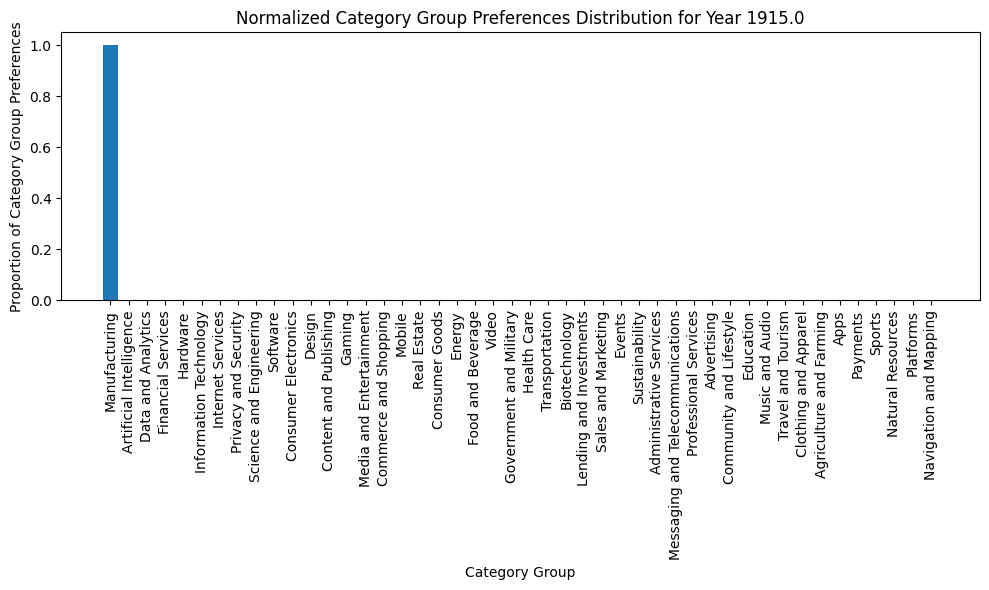

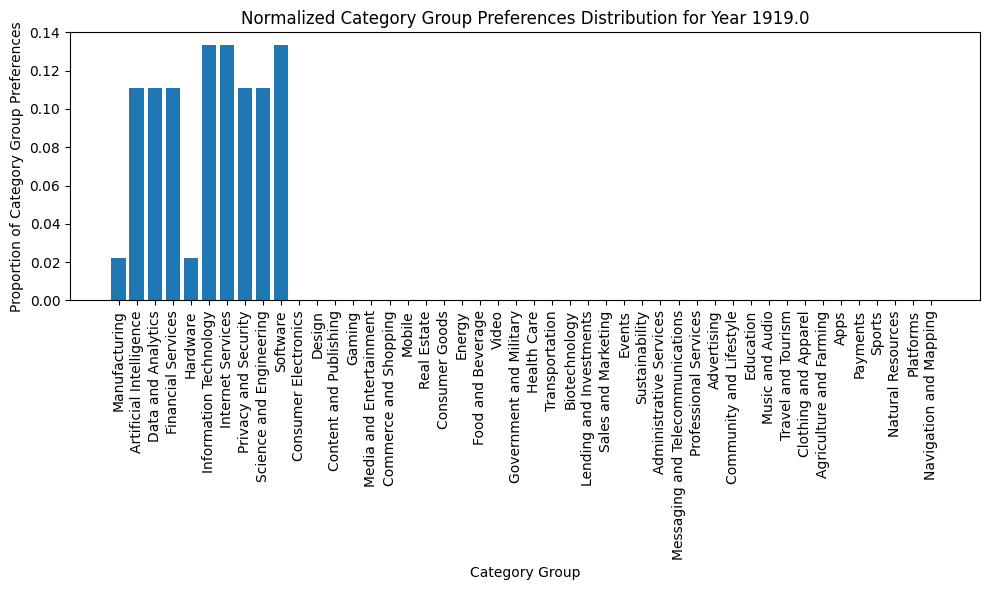

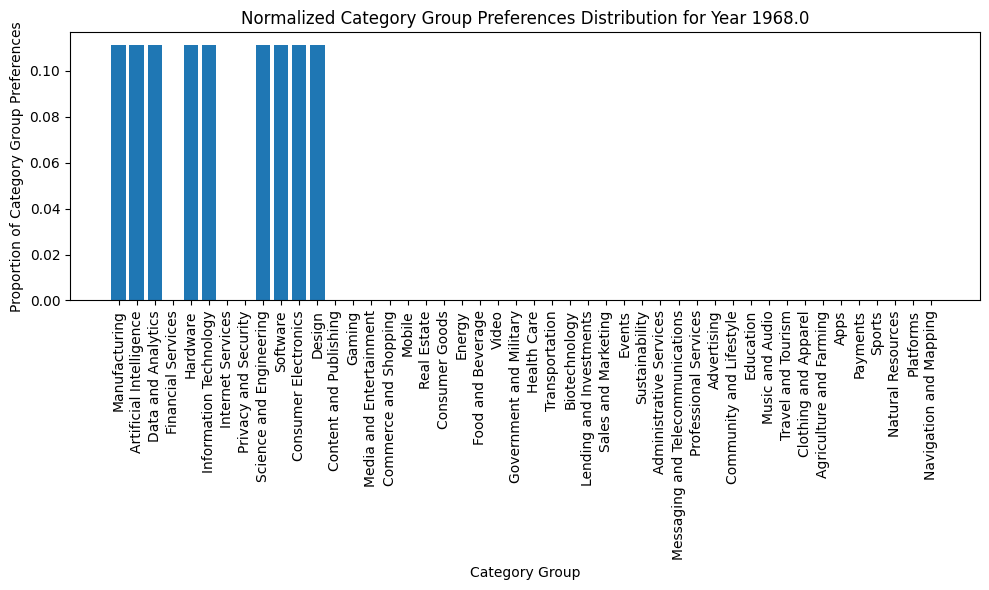

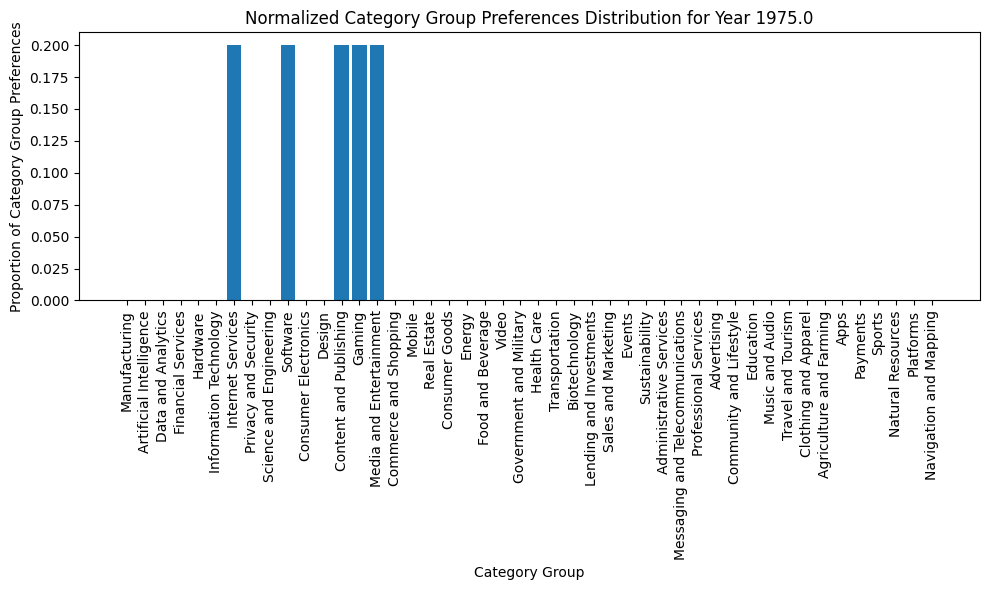

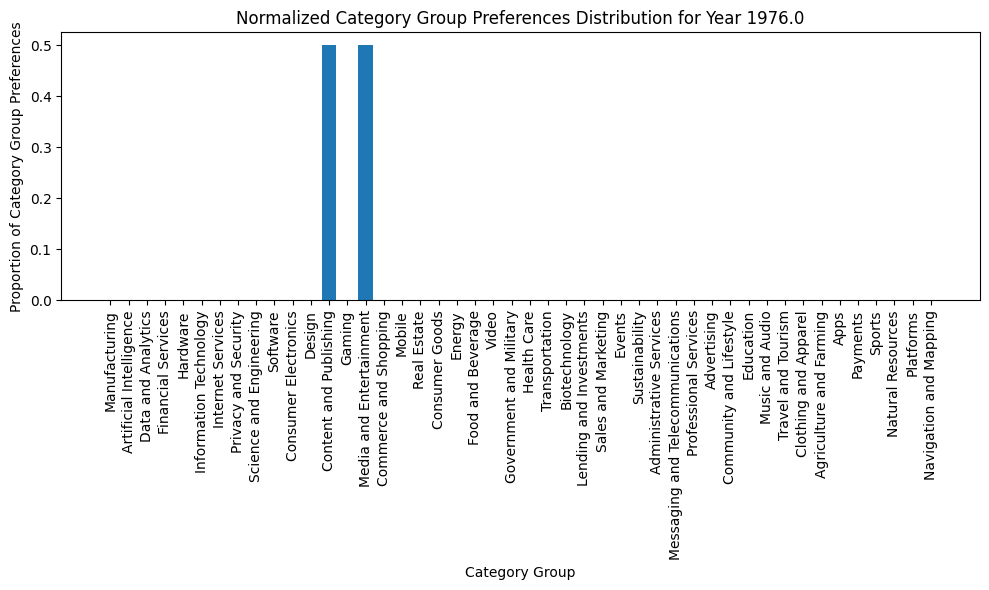

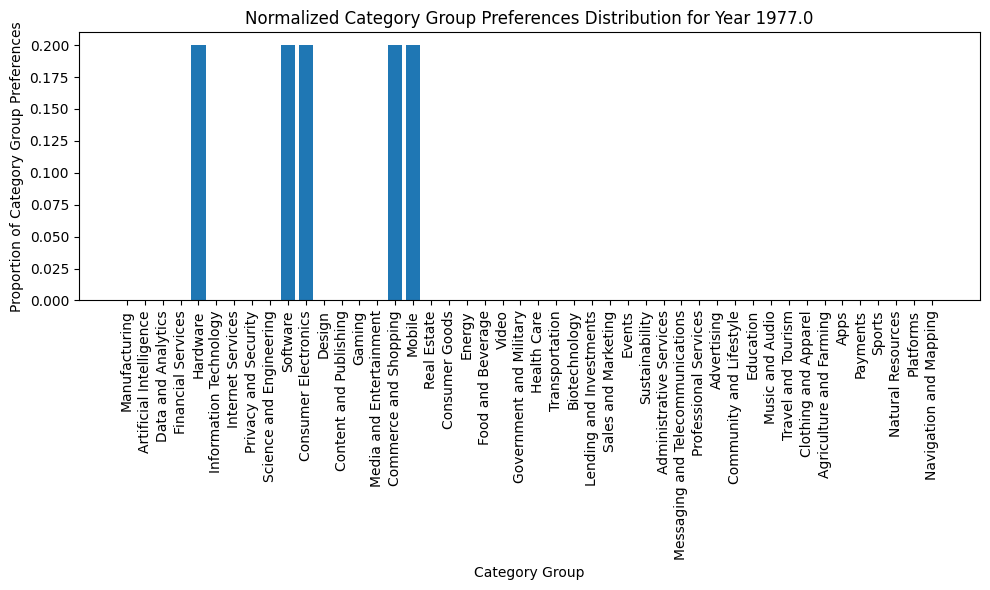

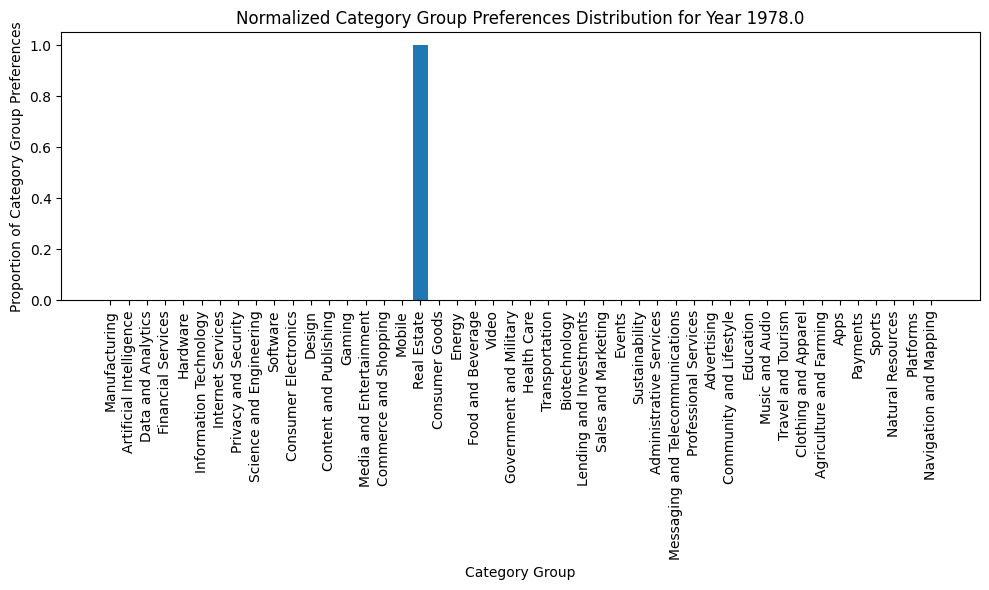

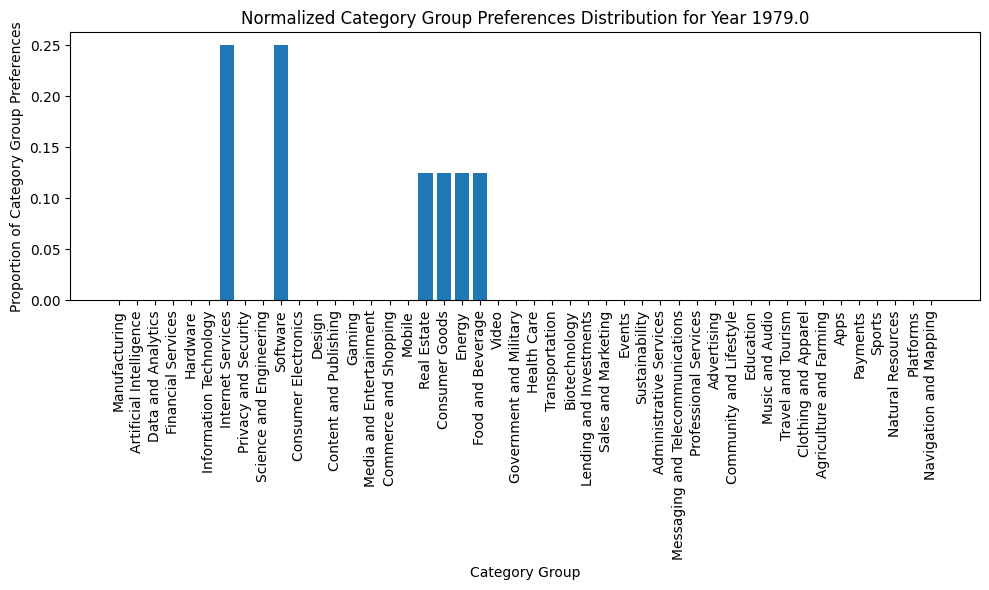

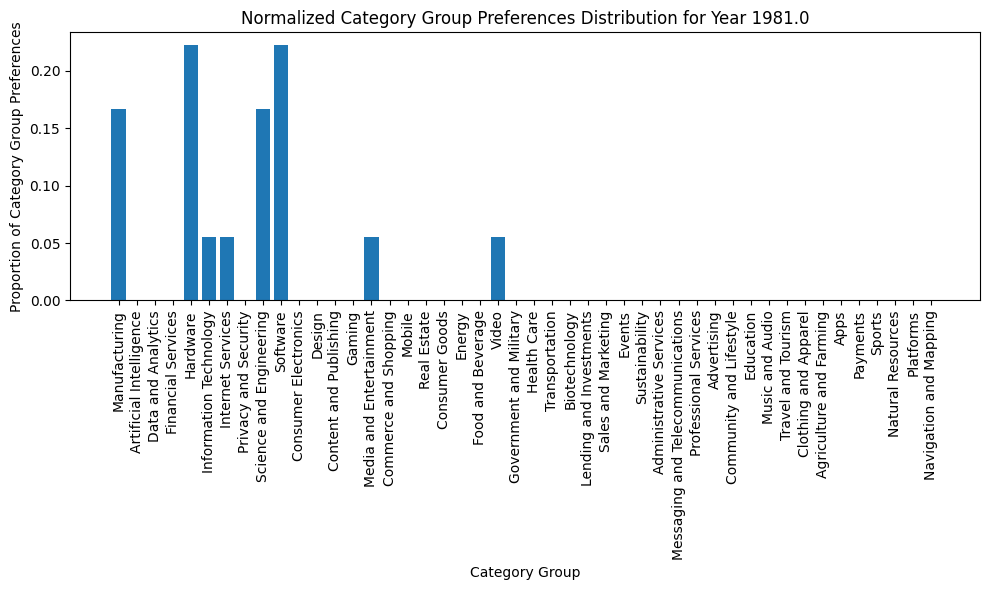

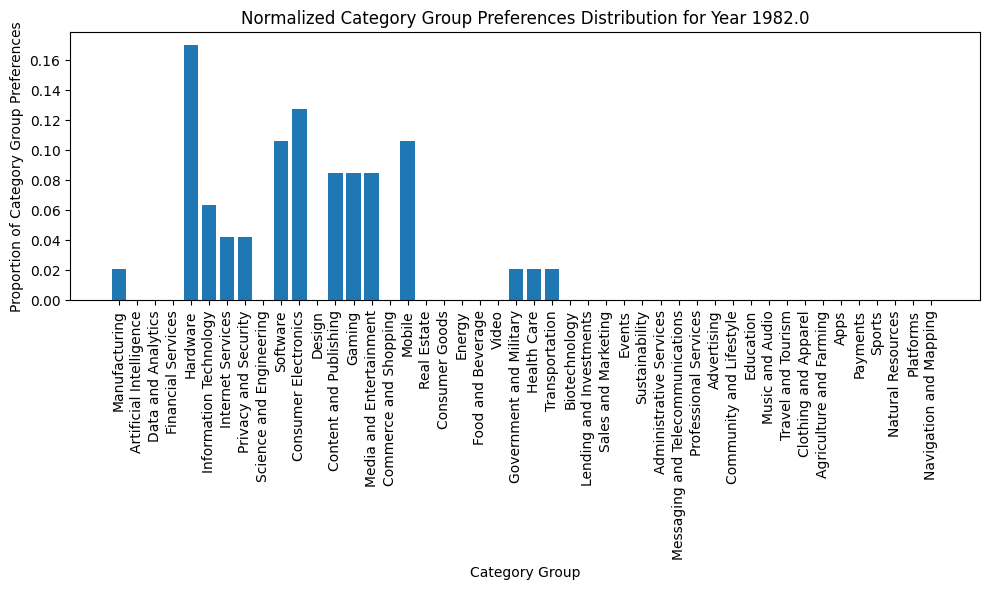

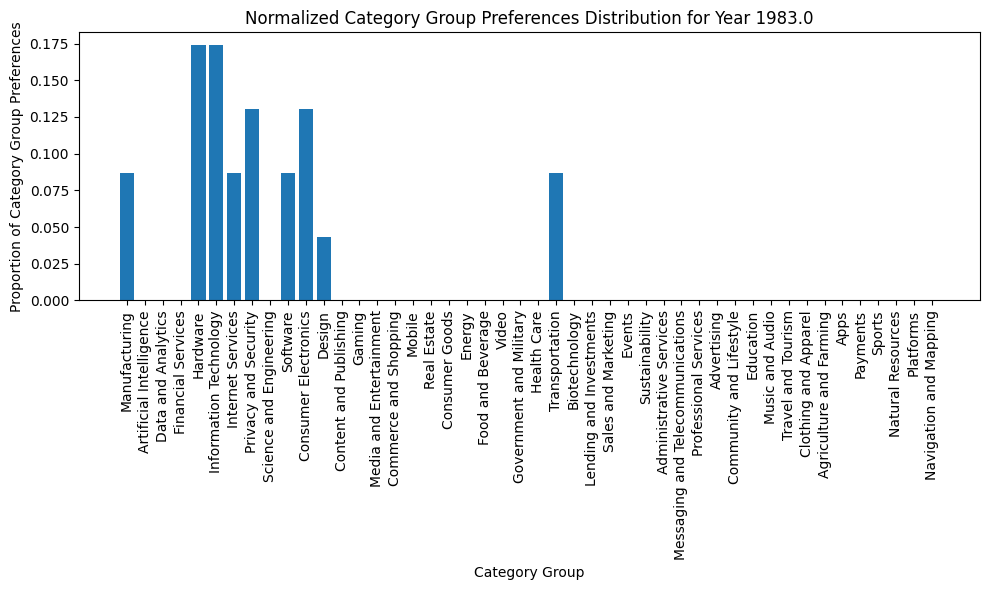

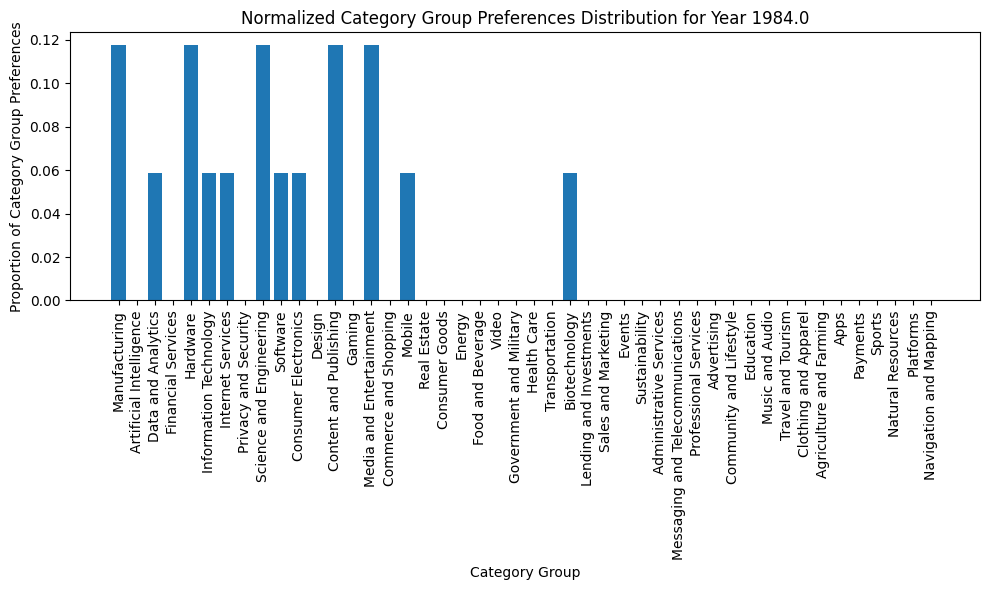

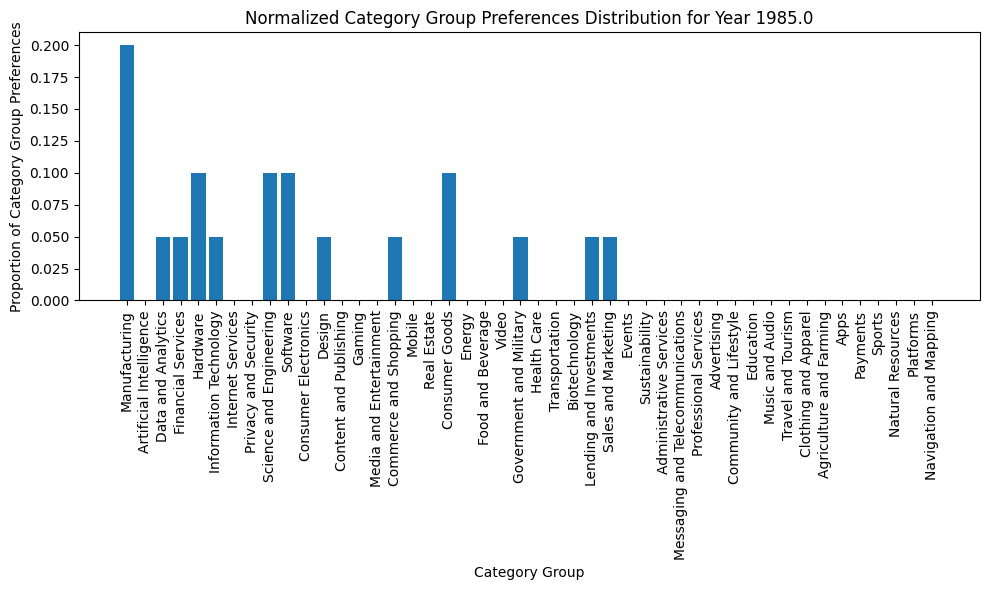

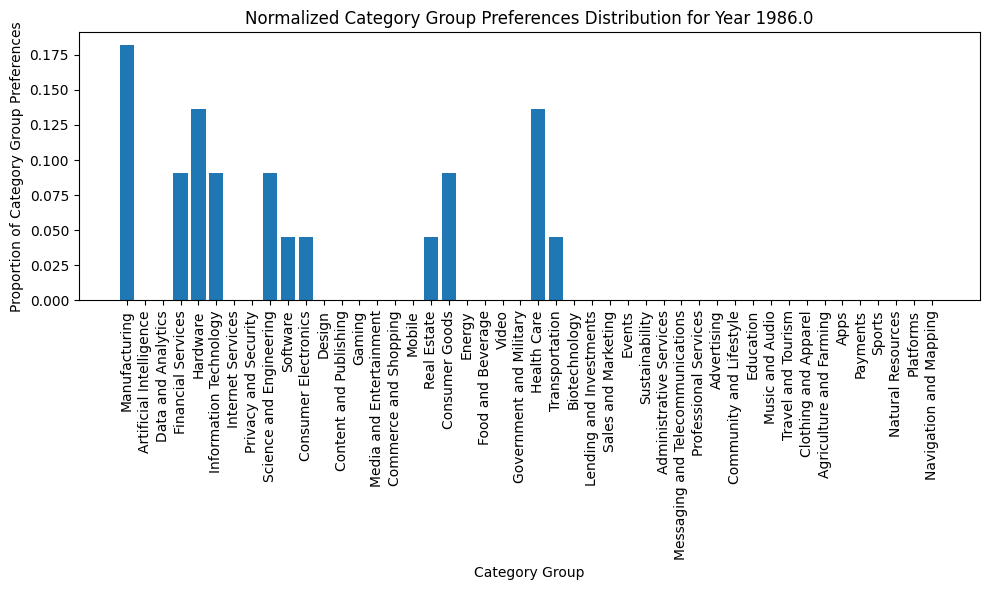

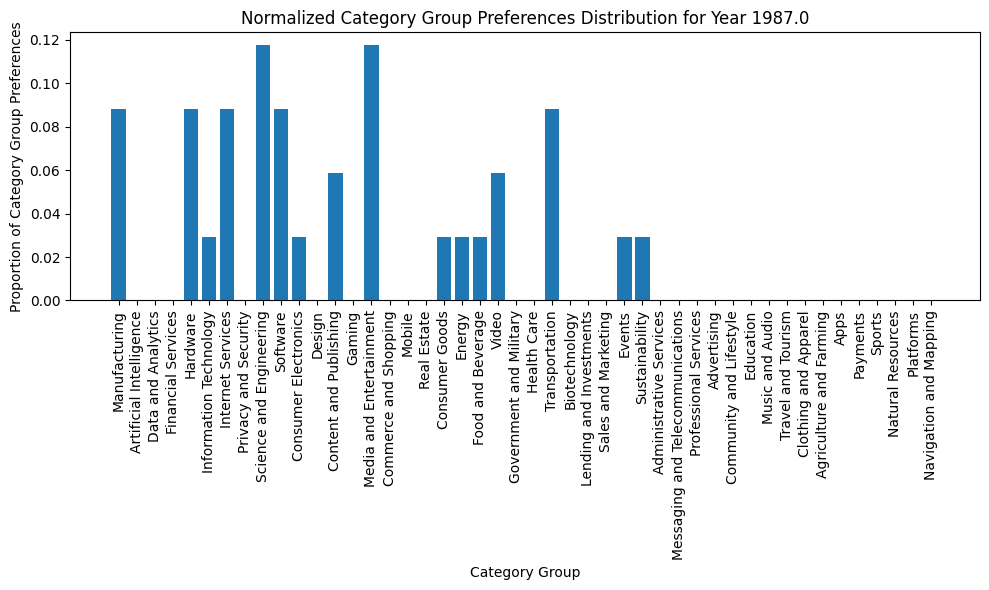

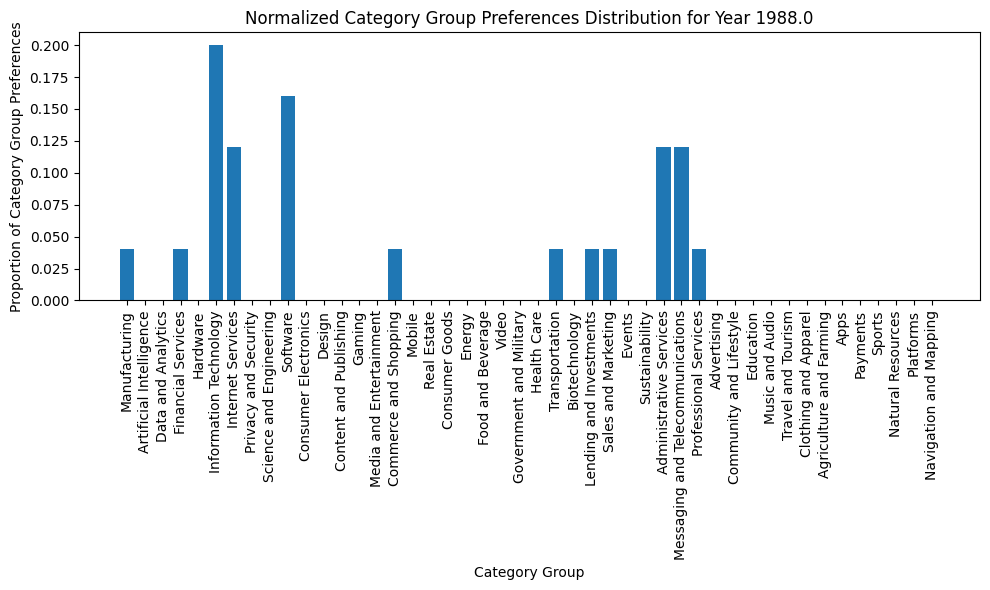

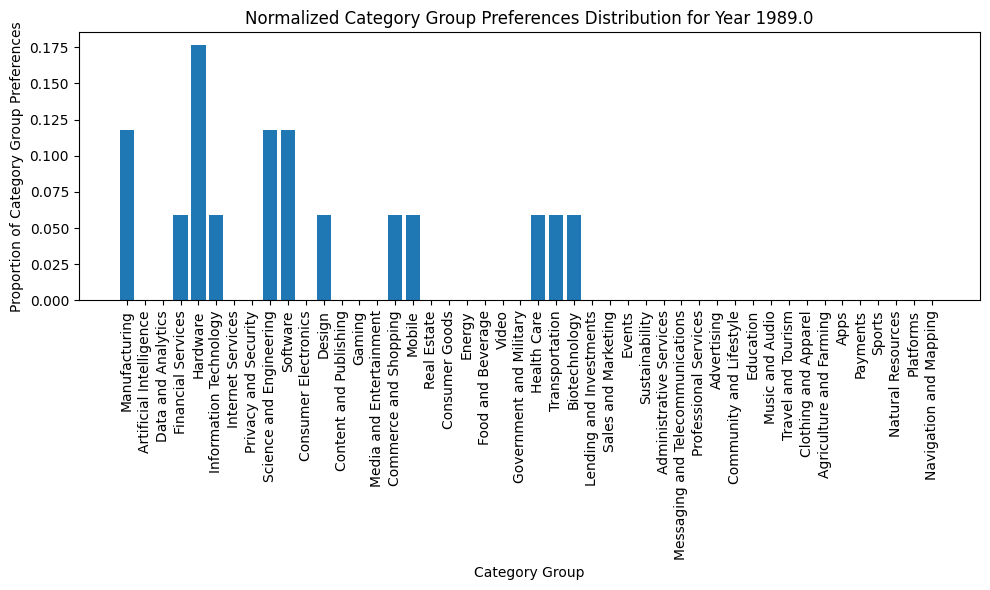

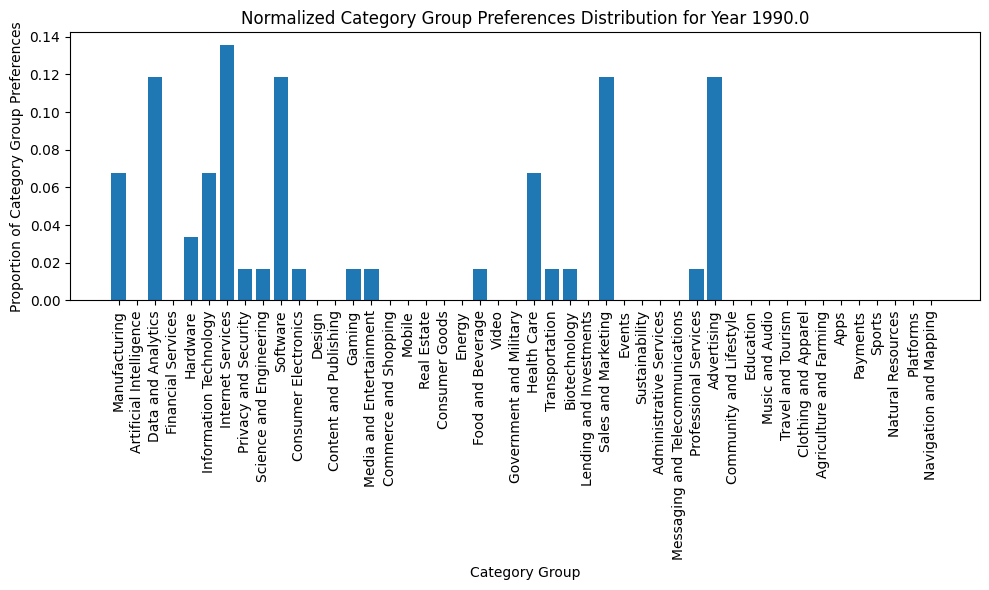

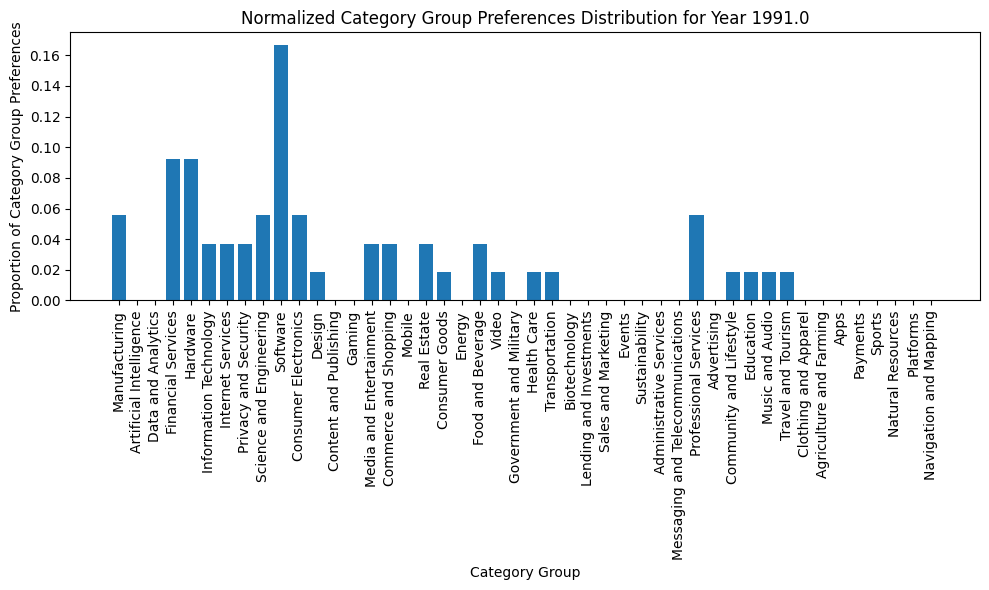

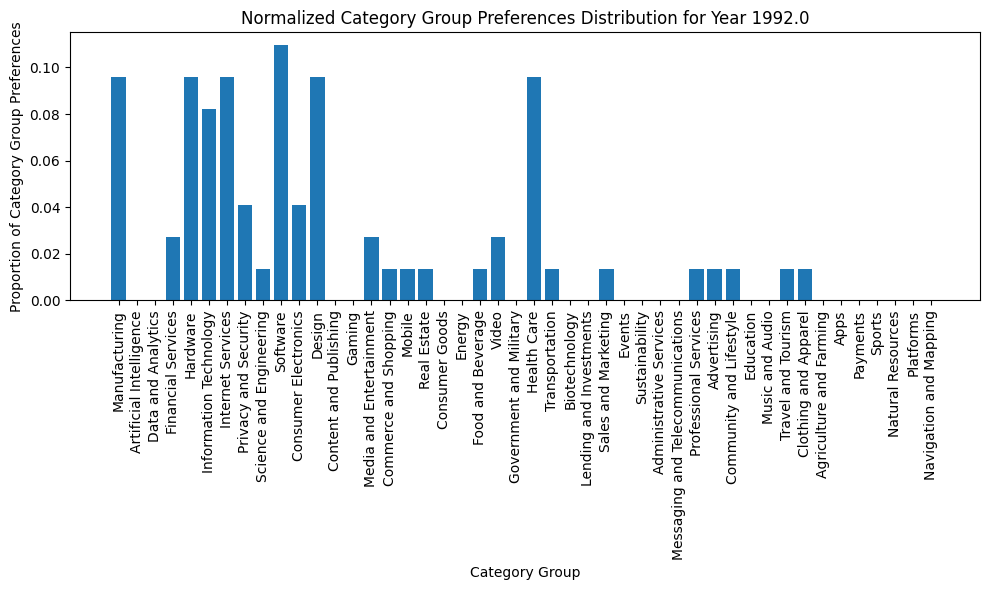

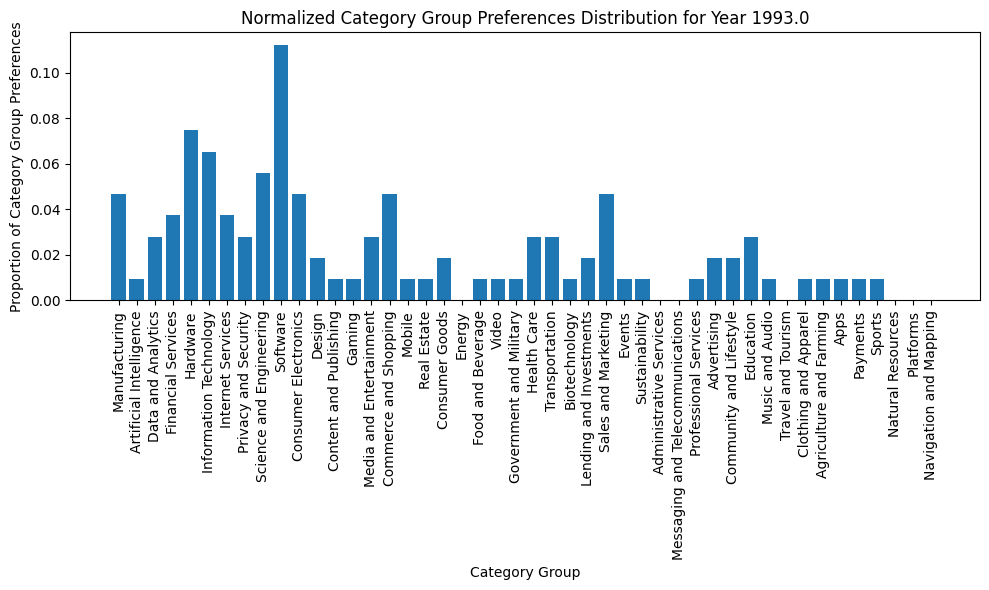

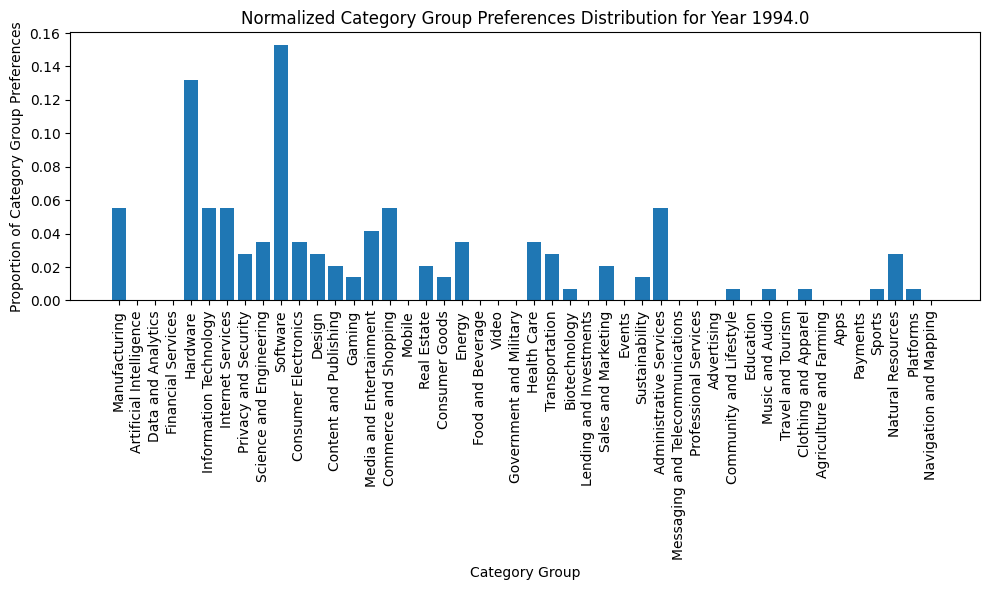

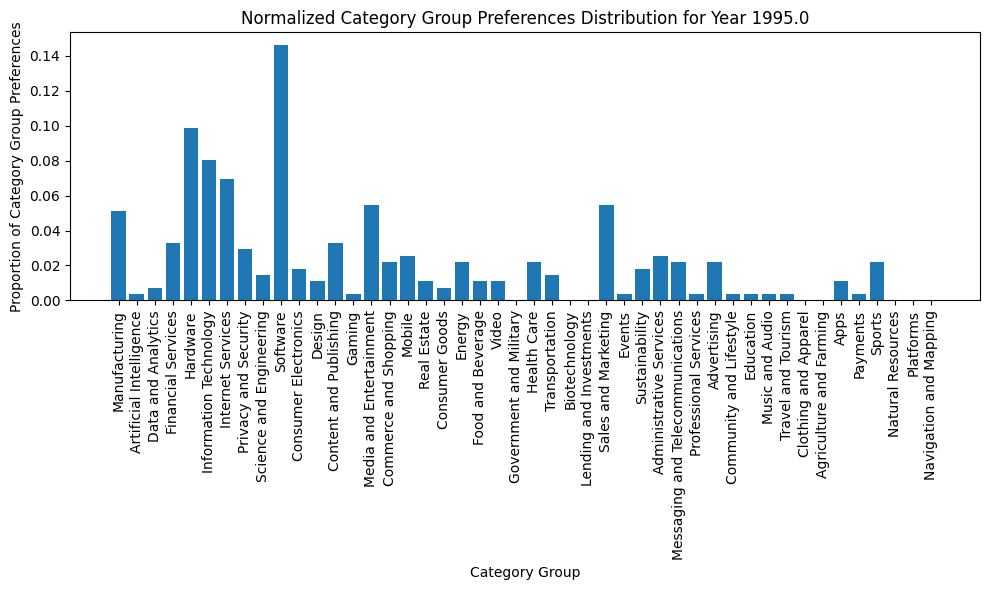

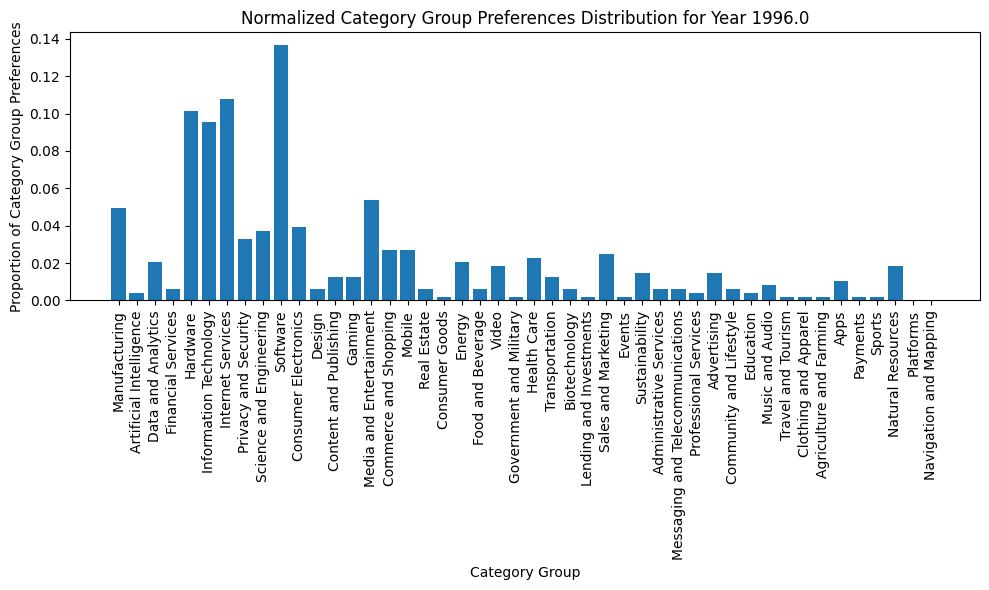

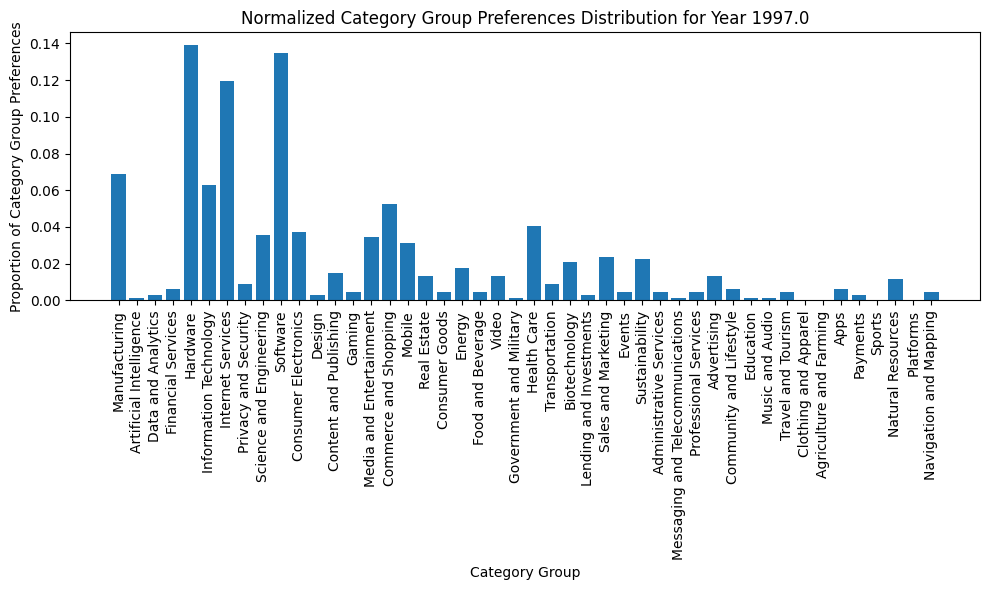

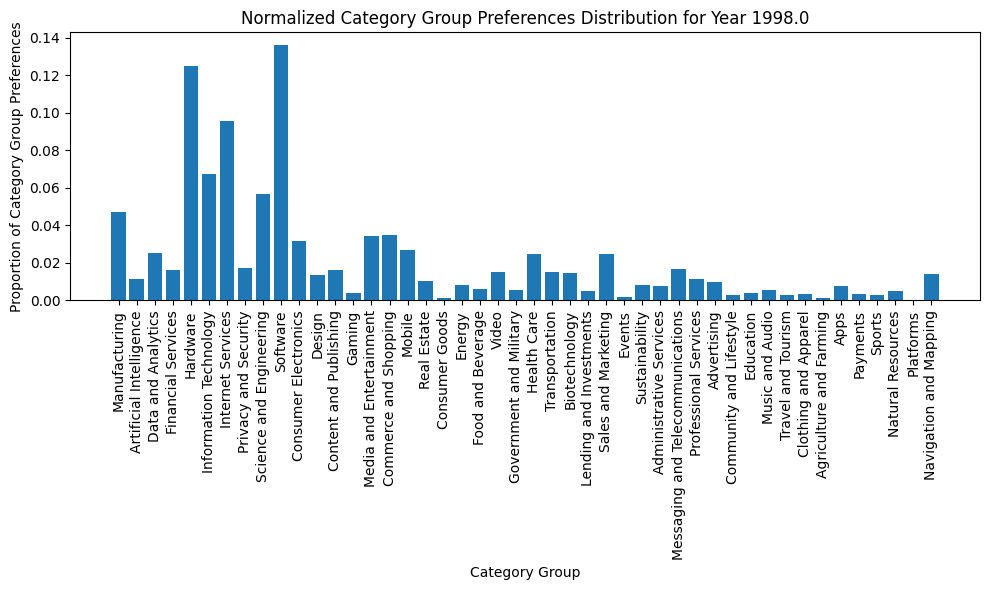

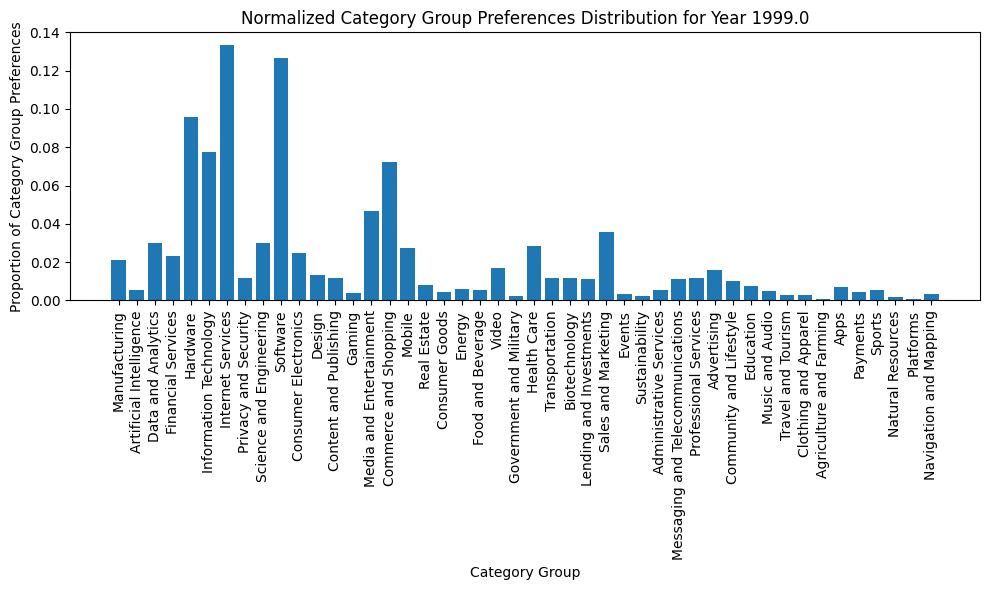

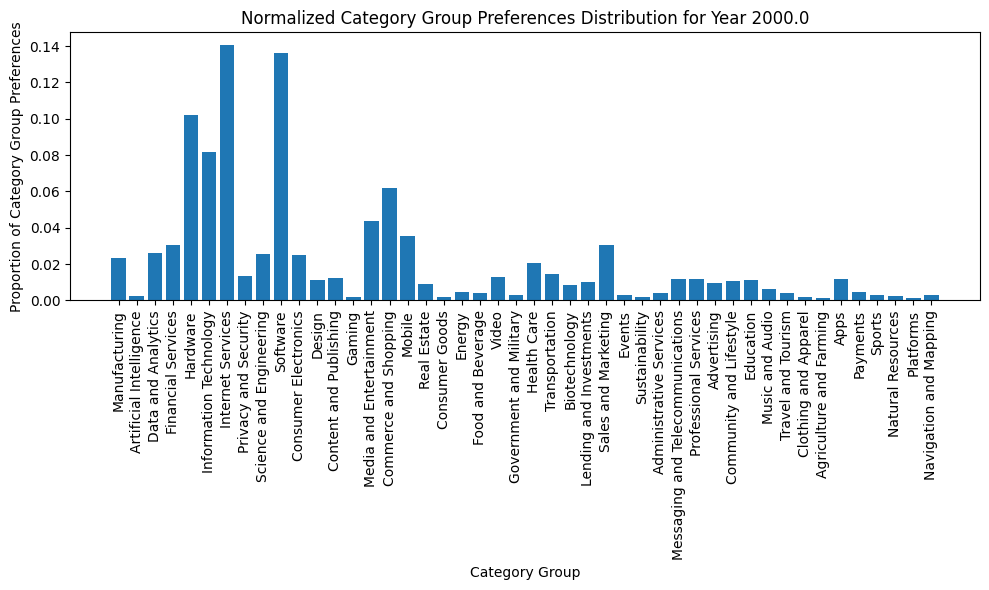

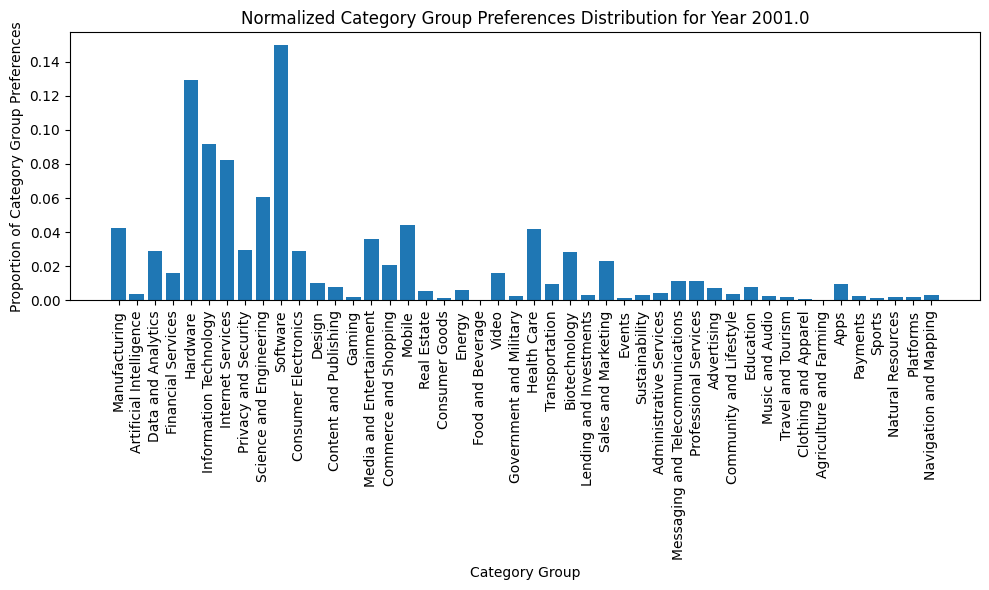

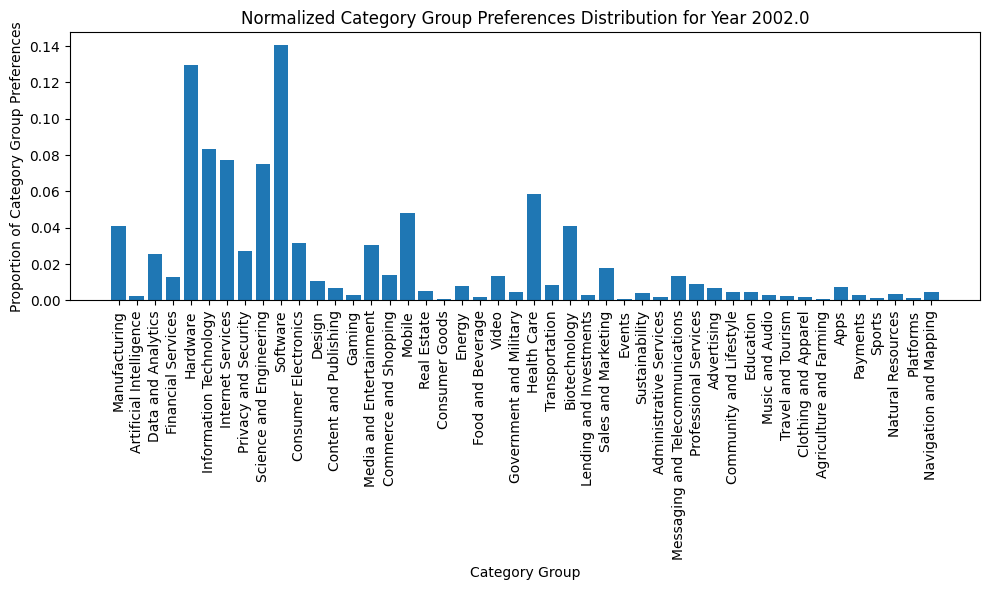

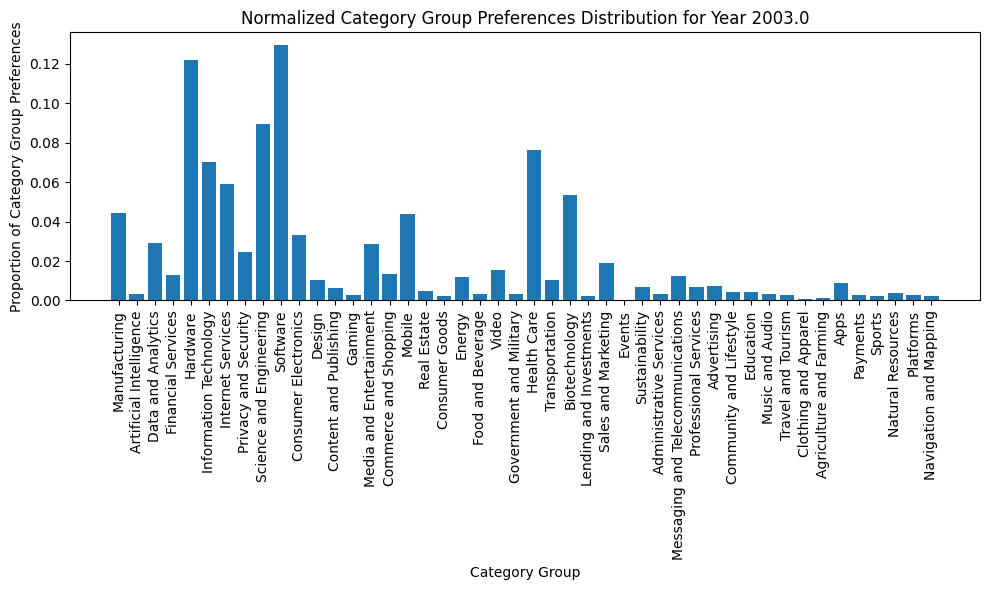

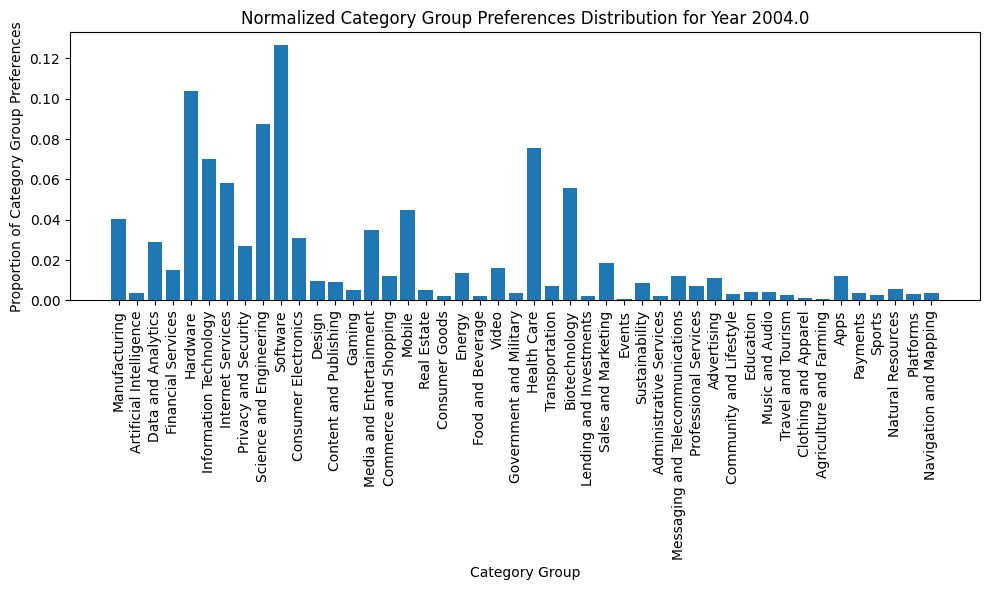

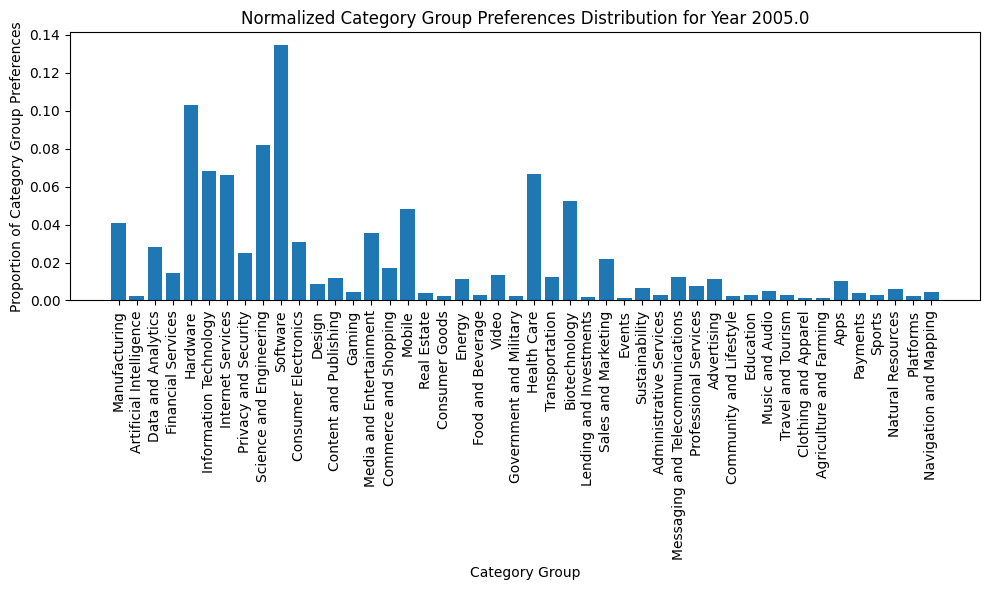

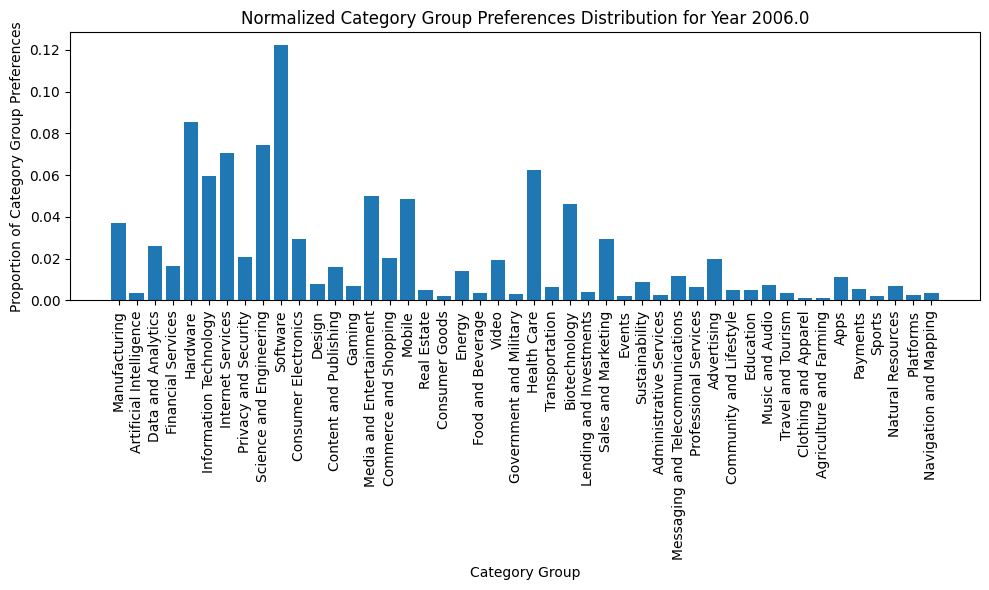

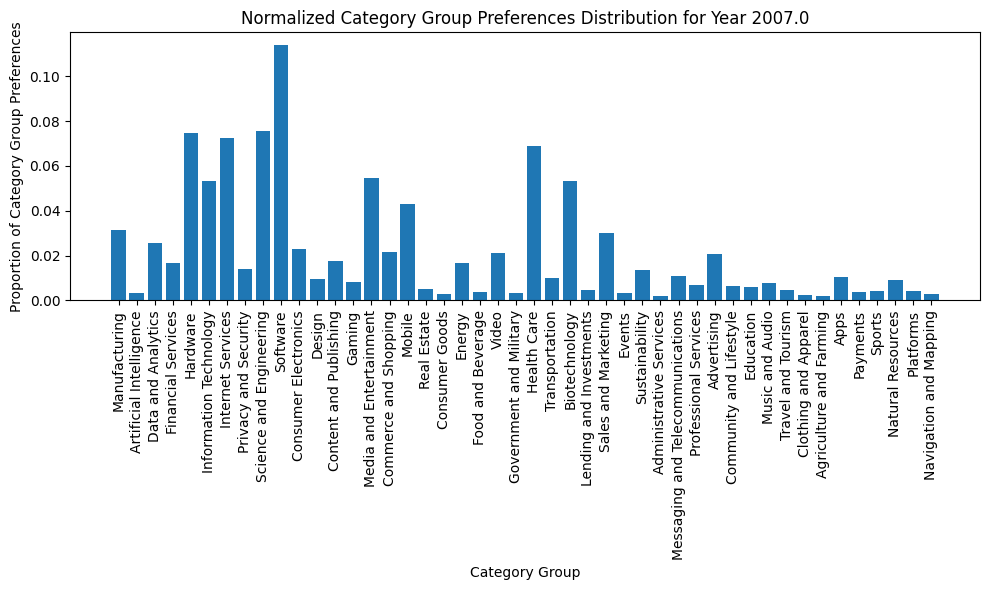

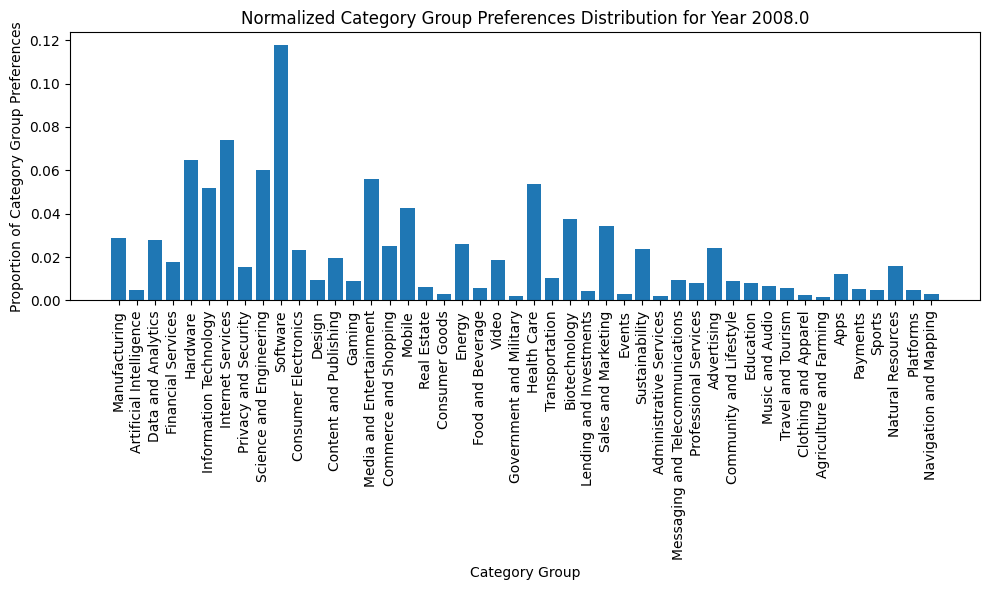

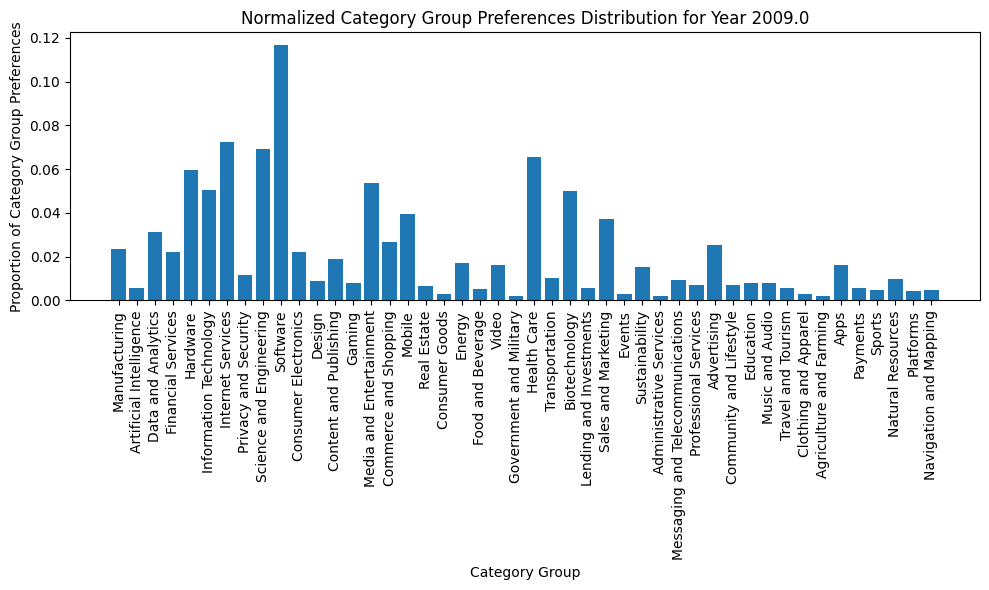

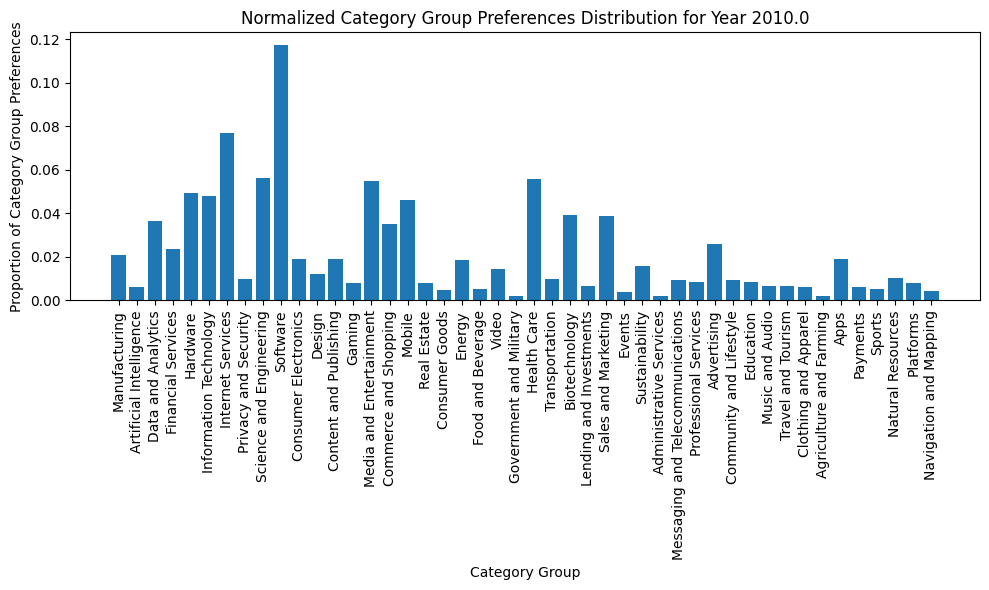

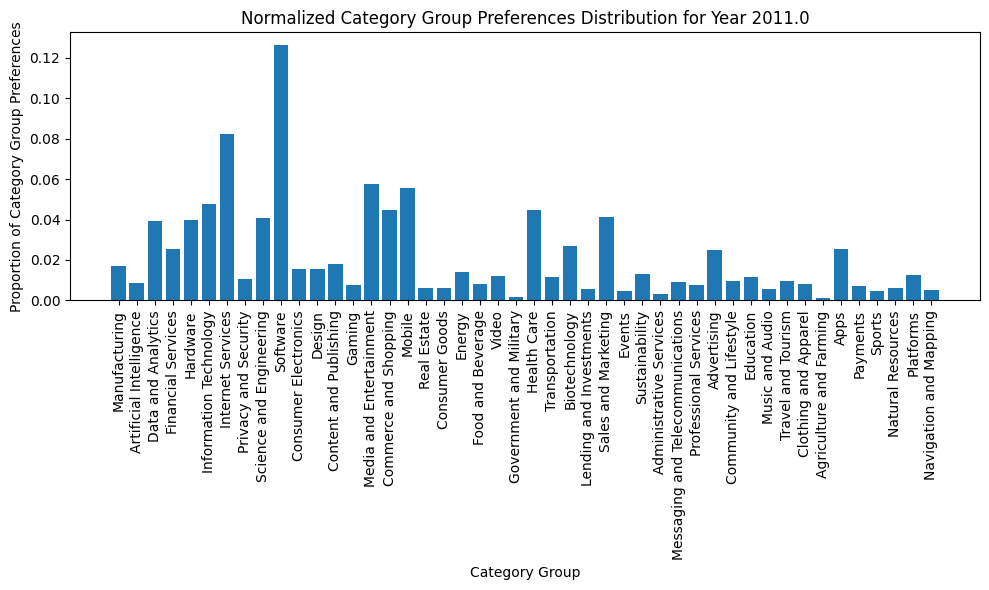

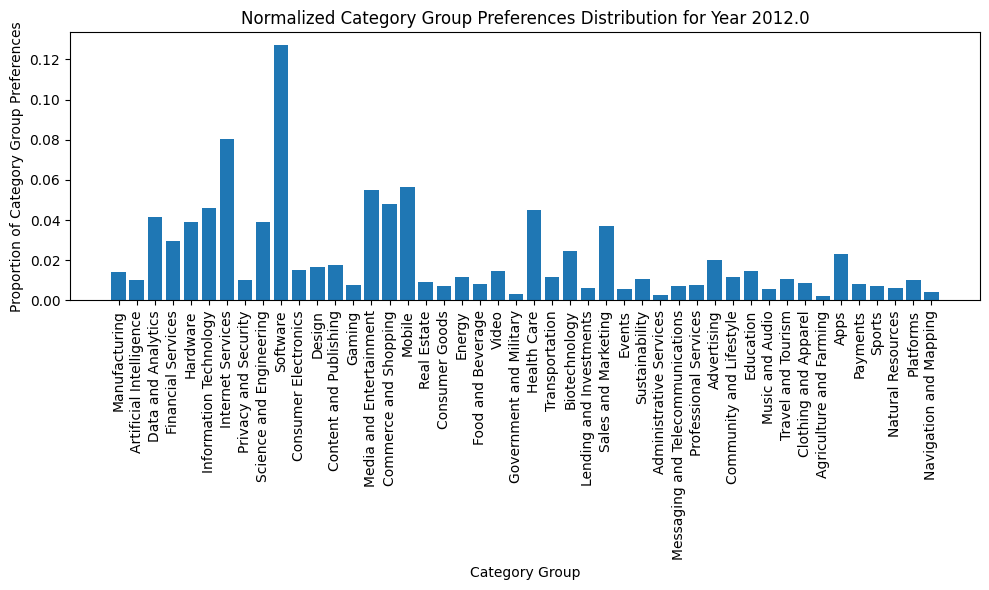

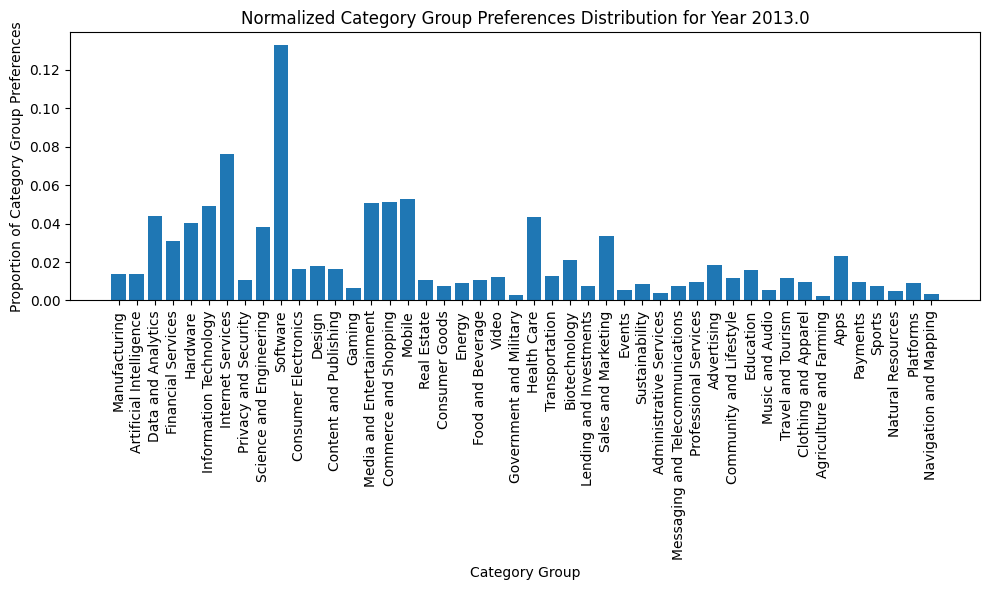

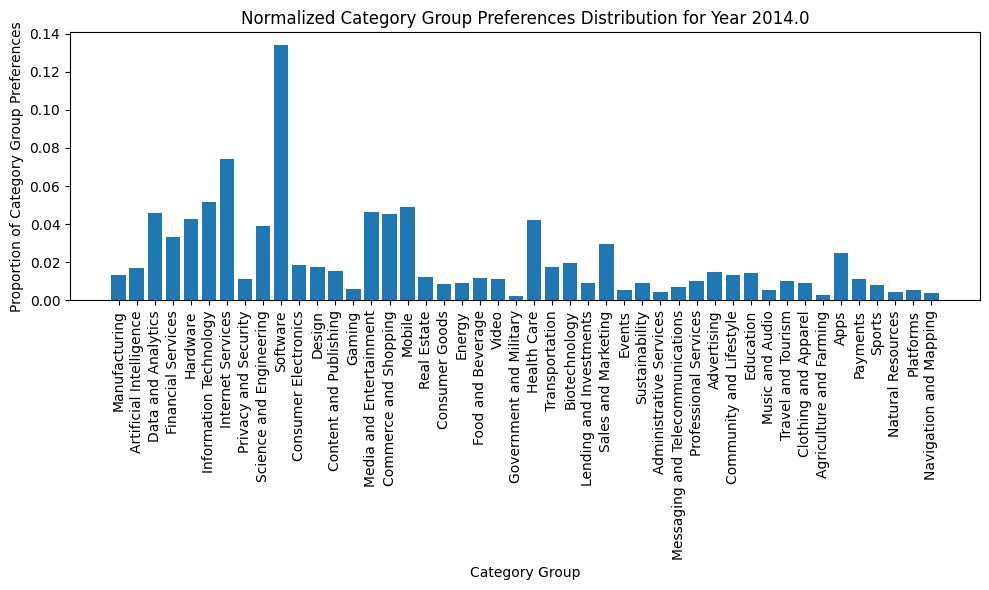

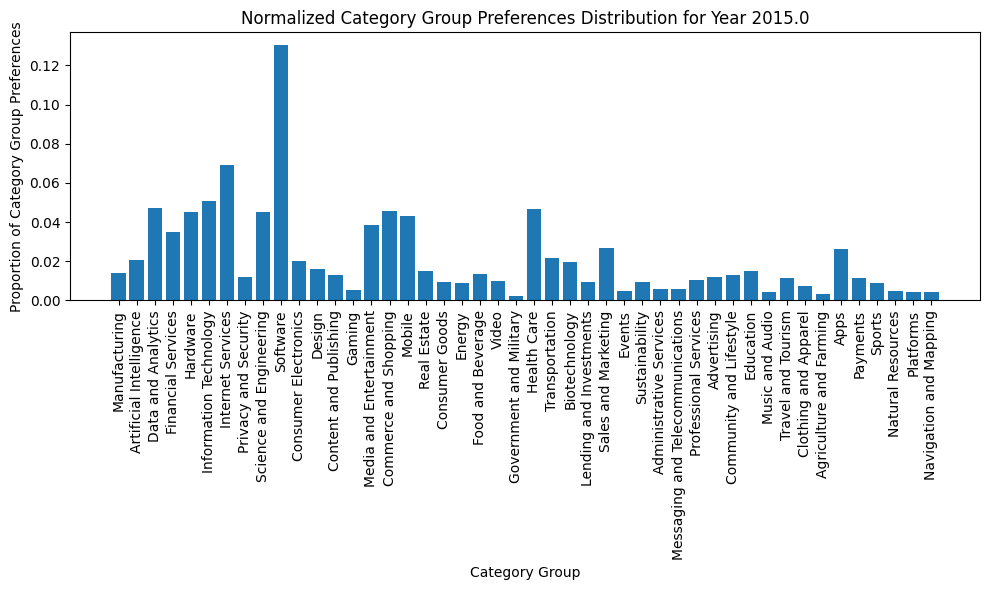

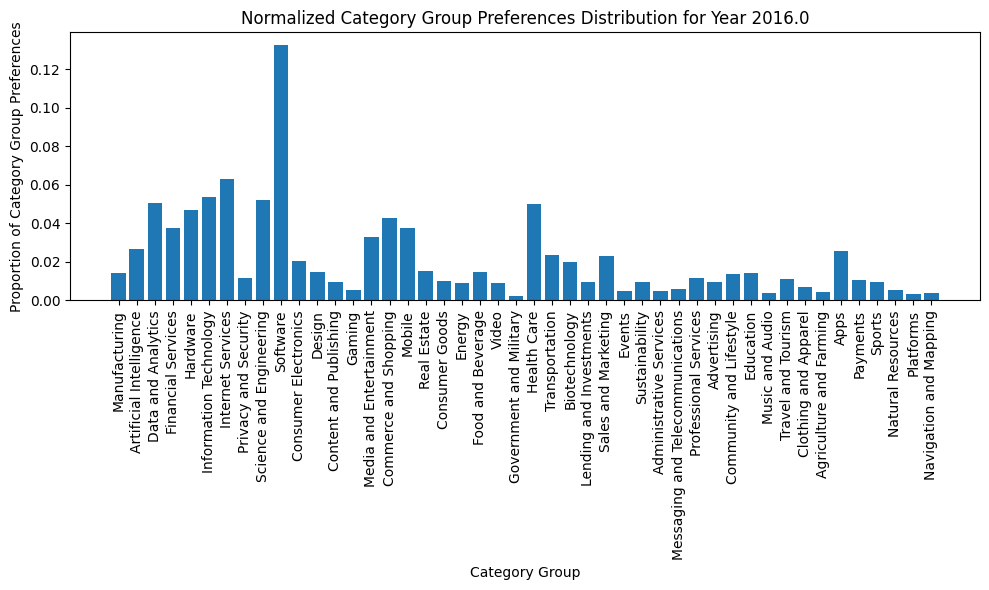

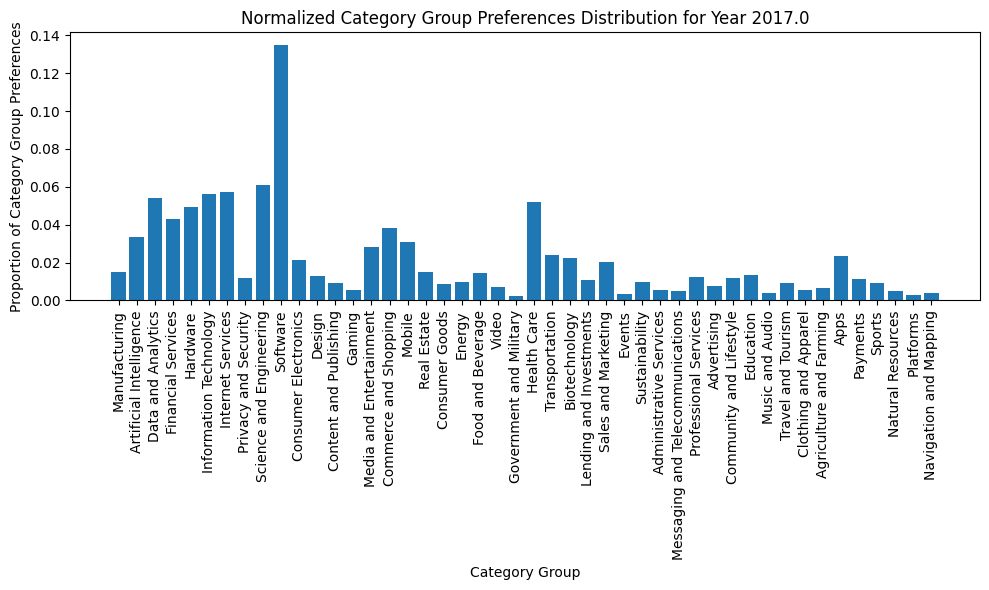

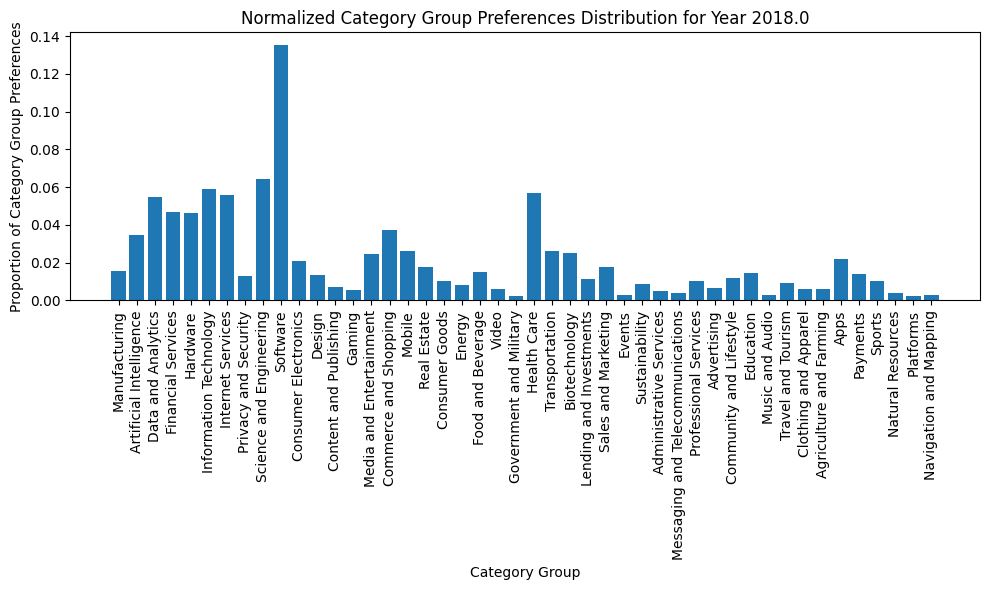

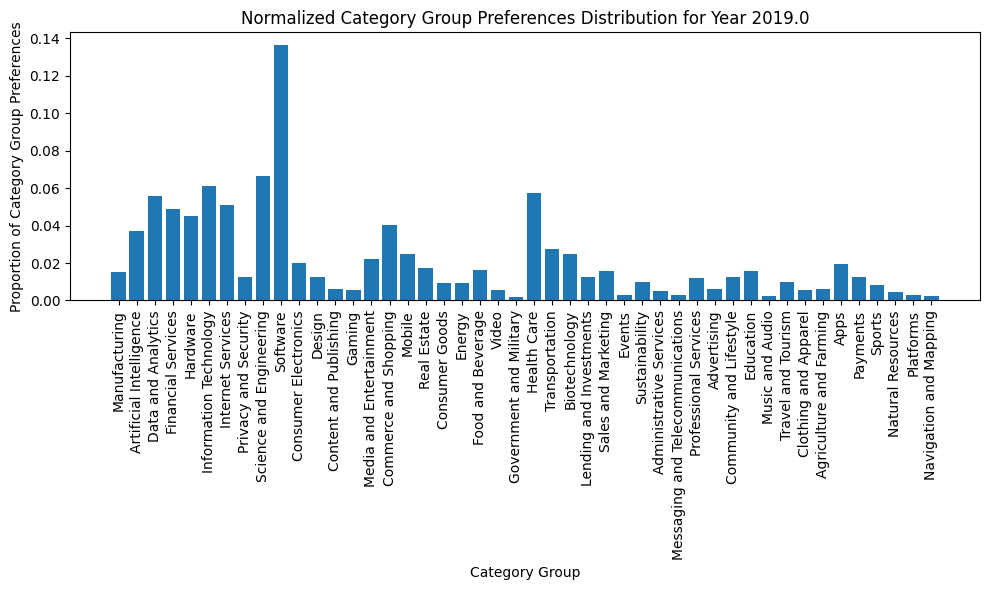

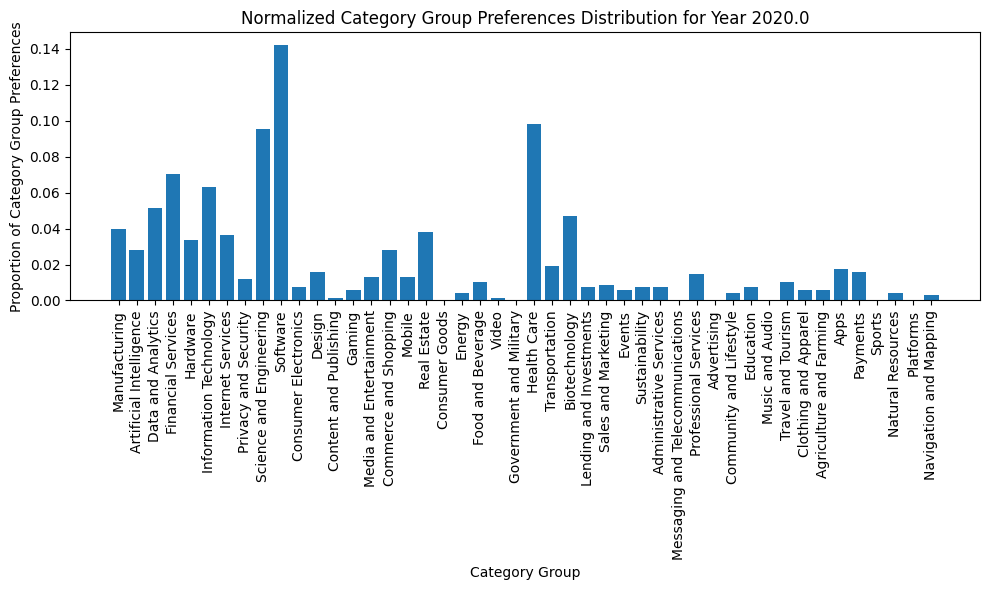

In [25]:
import matplotlib.pyplot as plt

df_normalized = df_group_yearly_sum.copy()
df_normalized = df_normalized[~df_normalized['year'].isin(['1915', '1919'])]

for index, row in df_normalized.iterrows():
    year = row['year']
    total_sum = row.drop('year').sum()
    df_normalized.loc[index, df_normalized.columns != 'year'] = row.drop('year') / total_sum

for index, row in df_normalized.iterrows():
    year = row['year']
    data = row.drop('year')

    plt.figure(figsize=(10, 6))
    plt.bar(data.index, data.values)
    plt.title(f'Normalized Category Group Preferences Distribution for Year {year}')
    plt.xlabel('Category Group')
    plt.ylabel('Proportion of Category Group Preferences')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [28]:
import scipy.spatial.distance as dist
from scipy.stats import wasserstein_distance

############## Jensen-Shannon Divergence ##############
JS_divergences = []
for i in range(1, len(df_normalized)):
    year1 = df_normalized.iloc[i - 1, 1:]  
    year2 = df_normalized.iloc[i, 1:]      
    divergence = dist.jensenshannon(year1, year2) **2
    JS_divergences.append((df_normalized.iloc[i]['year'], divergence))
    
df_JS = pd.DataFrame(JS_divergences, columns=['year', 'js'])
df_JS = df_JS[~df_JS['year'].isin(['1915', '1919'])]

############## Hellinger Distance ##############

def hellinger_distance(p, q):
    p = np.array(p)
    q = np.array(q)
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

HD_distances = []
for i in range(1, len(df_normalized)):
    year1 = df_normalized.iloc[i - 1, 1:]
    year2 = df_normalized.iloc[i, 1:]
    distance = hellinger_distance(year1, year2)
    HD_distances.append((df_normalized.iloc[i]['year'], distance))

df_HD = pd.DataFrame(HD_distances, columns=['year', 'hd'])
df_HD = df_HD[~df_HD['year'].isin(['1915', '1919'])]
############## Earth Mover Distnace ##############

EMD = []
for i in range(1, len(df_normalized)):
    year1 = df_normalized.iloc[i - 1, 1:]
    year2 = df_normalized.iloc[i, 1:]
    distance = wasserstein_distance(year1, year2)
    EMD.append((df_normalized.iloc[i]['year'], distance))

df_EMD = pd.DataFrame(EMD, columns=['year', 'emd'])
df_EMD = df_EMD[~df_EMD['year'].isin(['1915', '1919'])]
############## Total Variation Distance ##############

def tvd(p, q):
    return 0.5 * np.sum(np.abs(p - q))

TVD = []
for i in range(1, len(df_normalized)):
    year1 = df_normalized.iloc[i - 1, 1:]
    year2 = df_normalized.iloc[i, 1:]
    distance = tvd(year1, year2)
    TVD.append((df_normalized.iloc[i]['year'], distance))

df_TVD = pd.DataFrame(TVD, columns=['year', 'tvd'])
df_TVD = df_TVD[~df_TVD['year'].isin(['1915', '1919'])]

############## Average Distance ##############

df_merged = df_JS.merge(df_HD, on='year').merge(df_EMD, on='year').merge(df_TVD, on='year')
df_merged['avg_distance'] = df_merged[['js', 'hd', 'emd', 'tvd']].mean(axis=1)
df_avg = df_merged[['year', 'avg_distance']]

df_avg.to_csv('AVG_distribution_similarity.csv', index=False)

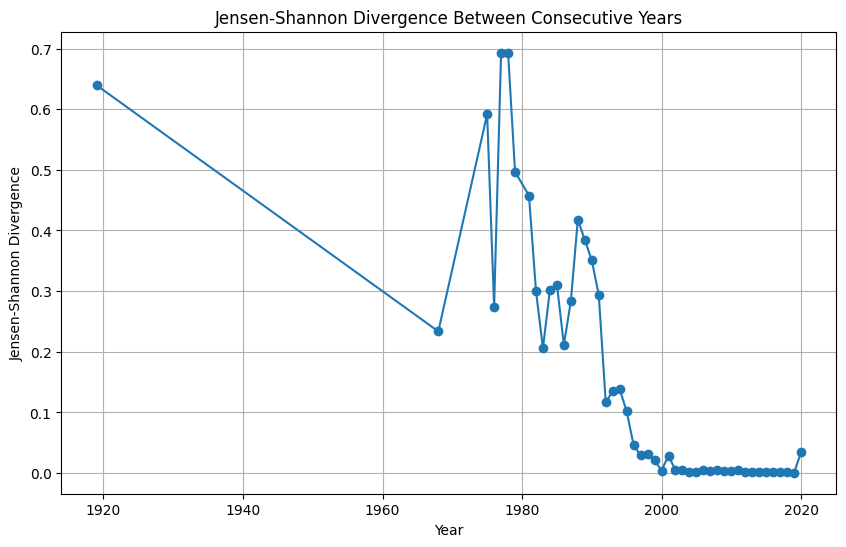

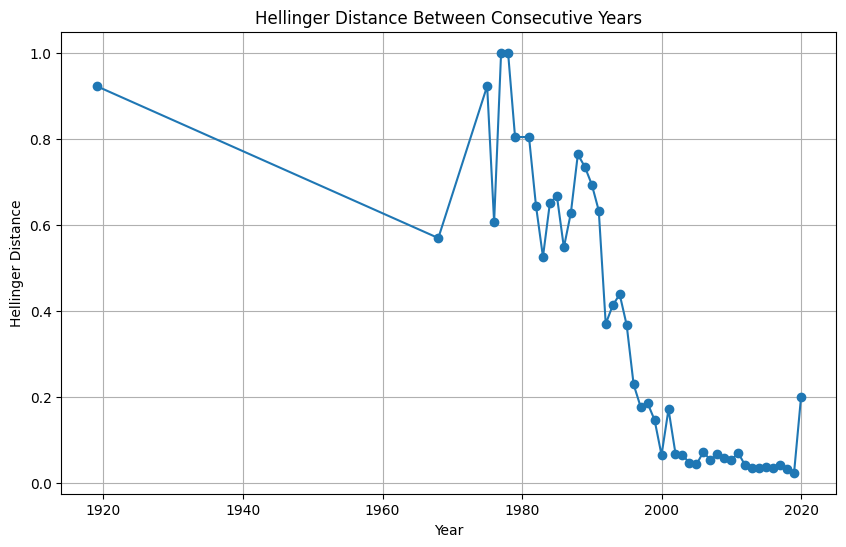

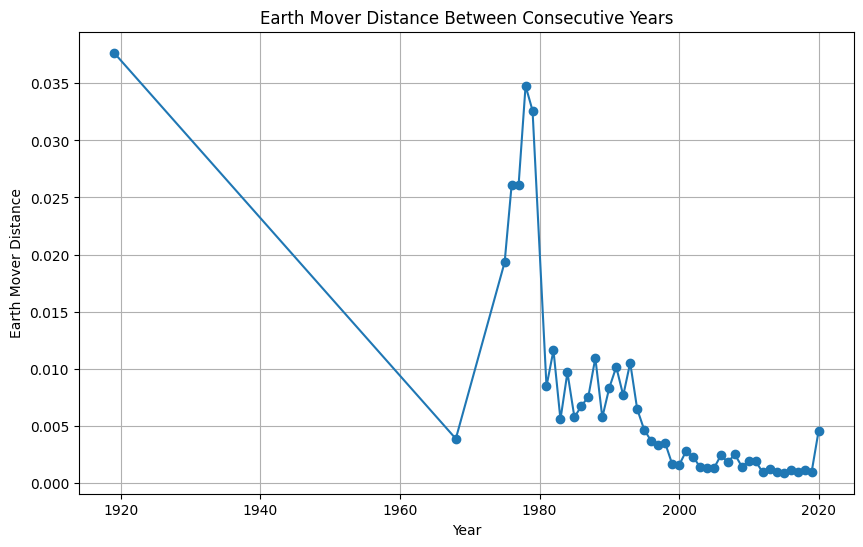

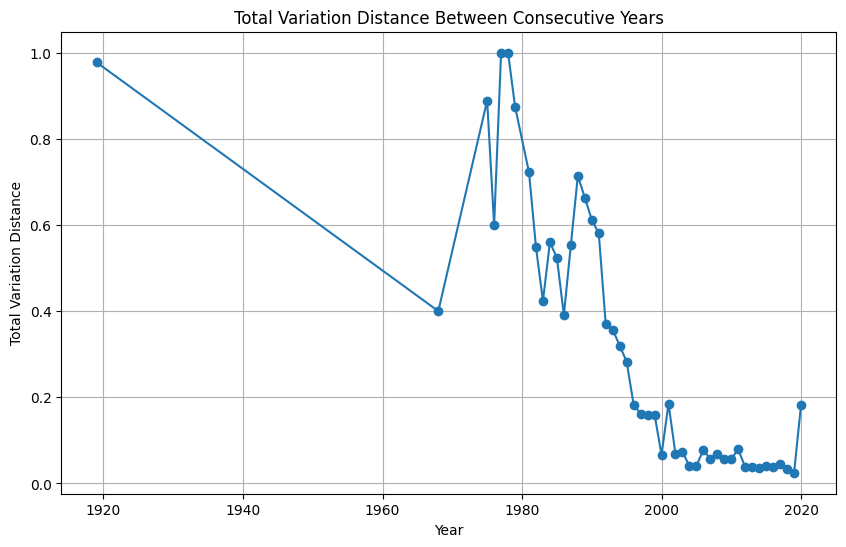

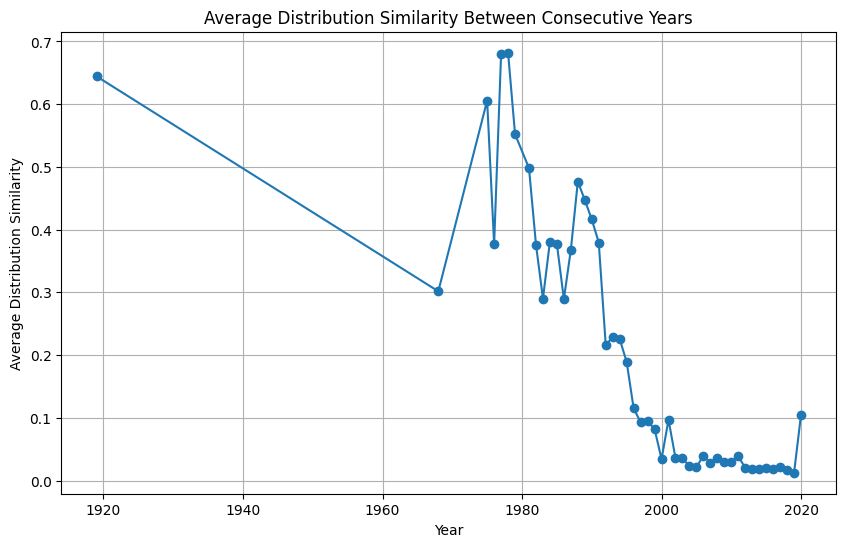

In [29]:
# Plots

plt.figure(figsize=(10, 6))
plt.plot(df_JS['year'], df_JS['js'], marker='o')
plt.title('Jensen-Shannon Divergence Between Consecutive Years')
plt.xlabel('Year')
plt.ylabel('Jensen-Shannon Divergence')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(df_HD['year'], df_HD['hd'], marker='o')
plt.title('Hellinger Distance Between Consecutive Years')
plt.xlabel('Year')
plt.ylabel('Hellinger Distance')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_EMD['year'], df_EMD['emd'], marker='o')
plt.title('Earth Mover Distance Between Consecutive Years')
plt.xlabel('Year')
plt.ylabel('Earth Mover Distance')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_TVD['year'], df_TVD['tvd'], marker='o')
plt.title('Total Variation Distance Between Consecutive Years')
plt.xlabel('Year')
plt.ylabel('Total Variation Distance')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_avg['year'], df_avg['avg_distance'], marker='o')
plt.title('Average Distribution Similarity Between Consecutive Years')
plt.xlabel('Year')
plt.ylabel('Average Distribution Similarity')
plt.grid(True)
plt.show()



## Rivalry Score Prediction

In [2]:
df_rs = pd.read_csv('rivalry_score_final.csv')
df_main = pd.read_csv('investor_startup.csv')
df_avg = pd.read_csv('AVG_distribution_similarity.csv')

C:\Users\wsswi\AppData\Local\Temp\ipykernel_11912\4024049755.py:2: DtypeWarning: Columns (31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_main = pd.read_csv('investor_startup.csv')


In [3]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix


current_year = 2020
# decay_rate = 0.03  # tuneable parameter (0.1 = 0.905 decay per year, 0.05 = 0.951 decay per year, 0.03 = 0.970 decay per year)

df_avg['avg_distance'] = np.exp(df_avg['avg_distance'])
df_combined = pd.merge(df_rs, df_avg, on='year')
df_rs['adjusted_score'] = df_combined['rivalry_score'] * df_combined['avg_distance']

# mapping investors to indices
investors = list(set(df_rs['investor1']).union(set(df_rs['investor2'])))
investor_to_index = {investor: idx for idx, investor in enumerate(investors)}

# create sparse matrix
rows = []
cols = []
data = []

for _, row in df_rs.iterrows():
    i = investor_to_index[row['investor1']]
    j = investor_to_index[row['investor2']]
    score = row['adjusted_score']
    rows.append(i)
    cols.append(j)
    data.append(score)
    rows.append(j)
    cols.append(i)
    data.append(score) 

num_investors = len(investors)
rivalry_sparse_matrix = csr_matrix((data, (rows, cols)), shape=(num_investors, num_investors))

# train mdoel
model = NearestNeighbors(metric='cosine', algorithm='brute')
model.fit(rivalry_sparse_matrix)




NearestNeighbors(algorithm='brute', metric='cosine')

In [4]:
df_search = pd.concat([df_main['investor_uuid'], df_main['investor_name']], axis=1)
df_search = df_search.drop_duplicates()
df_search.to_csv('investor_name_uuid_search.csv')

In [5]:
df_search = pd.read_csv('investor_name_uuid_search.csv')

def get_rival(investor_name, n_neighbors):
    global df_search
    investor_uuid = df_search[df_search['investor_name'] == investor_name]['investor_uuid'].values[0]
    if investor_uuid not in investor_to_index:
        return None
    investor_idx = investor_to_index[investor_uuid]
    distances, indices = model.kneighbors(rivalry_sparse_matrix[investor_idx], n_neighbors=n_neighbors+1)
    rival_indices = indices.flatten()[1:]  # exclude itself
    rival_uuids = [investors[idx] for idx in rival_indices if idx < len(investors)]
    rival_names = [df_search[df_search['investor_uuid'] == uuid]['investor_name'].values[0] for uuid in rival_uuids]
    return rival_names

In [6]:
get_rival('Blumberg Capital',10)

['Crosslink Capital',
 'Plug and Play',
 'Great Oaks Venture Capital',
 'GV',
 'General Catalyst',
 'Alchemist Accelerator',
 'Index Ventures',
 'Founders Fund',
 'True Ventures',
 'Social Capital']

In [83]:
investors = ['Accel', 'JP Morgan Chase', 'Goldman Sachs', 'Morgan Stanley', 'Bank of America', 'Citigroup', 'Wells Fargo', 'UBS', 'Deutsche Bank', 'Credit Suisse', 'HSBC','Bessemer Venture Partners', 'Sequoia Capital', 'Benchmark', 'Greylock Partners', 'Kleiner Perkins', 'Andreessen Horowitz', 'Founders Fund', 'First Round Capital', 'SV Angel']
num = 10

columns = ['Investor'] + [f'Competitor {i}' for i in range(1, num+1)]
df_rivals = pd.DataFrame(columns=columns)
for investor in investors:
    rivals = get_rival(investor, num)
    if rivals is None:
        rivals = ['None'] * num
    new_row = [investor] + rivals
    df_rivals.loc[len(df_rivals)] = new_row

In [84]:
df_rivals

,Investor,Competitor 1,Competitor 2,Competitor 3,Competitor 4,Competitor 5,Competitor 6,Competitor 7,Competitor 8,Competitor 9,Competitor 10
0,Accel,Lightspeed Venture Partners,Menlo Ventures,Redpoint,Greylock Partners,Norwest Venture Partners,CRV,Foundation Capital,IVP (Institutional Venture Partners),Kleiner Perkins,Battery Ventures
1,JP Morgan Chase,Kohlberg Kravis Roberts,Morgan Stanley,TPG,Goldman Sachs,New Enterprise Associates,Mohr Davidow Ventures,Warburg Pincus,Silicon Valley Bank,TPG Growth,Adams Street Partners
2,Goldman Sachs,Menlo Ventures,Norwest Venture Partners,Intel Capital,Kleiner Perkins,Bessemer Venture Partners,Redpoint,Sequoia Capital,Accel,Lightspeed Venture Partners,Foundation Capital
3,Morgan Stanley,Mohr Davidow Ventures,Canaan Partners,Tech Coast Angels,Venrock,Adams Street Partners,New Enterprise Associates,Silicon Valley Bank,InterWest Partners,T. Rowe Price,U.S. Venture Partners (USVP)
4,Bank of America,J & W Seligman,Bowman Capital,Amerindo Investment Advisors,TCV,Oak Investment Partners,Spectrum Equity,Morgan Stanley Dean Witter,Integral Capital Partners,ComVentures,Sandler Capital
5,Citigroup,JP Morgan,Natixis,Goldman Sachs Principal Strategic Investments,Wells Fargo,Credit Suisse,Point72 Ventures,UBS,BNP Paribas Private Equity,Deutsche Bank,Barclays
6,Wells Fargo,Point72 Ventures,JP Morgan,Goldman Sachs Principal Strategic Investments,JP Morgan Chase,Credit Suisse,Silicon Valley Bank,Morgan Stanley,Dreamers VC,Goldman Sachs,Citi Ventures
7,UBS,Natixis,Deutsche Bank,JP Morgan,Goldman Sachs Principal Strategic Investments,Wells Fargo,Bank of America,Citigroup,Credit Suisse,JP Morgan Chase,BNP Paribas Private Equity
8,Deutsche Bank,Morgan Stanley Dean Witter,J & W Seligman,JP Morgan Chase,UBS,Bowman Capital,Oak Investment Partners,JP Morgan,Wells Fargo,Spectrum Equity,Bank of America
9,Credit Suisse,Morgan Stanley,JP Morgan Chase,Silicon Valley Bank,Wells Fargo,Canaan Partners,Mohr Davidow Ventures,Venrock,New Enterprise Associates,Goldman Sachs,Citigroup


In [85]:
df_rivals.to_csv('top_10_rivals_case_study.csv')

In [86]:
get_rival('Accel', 10)

['Lightspeed Venture Partners',
 'Menlo Ventures',
 'Redpoint',
 'Greylock Partners',
 'CRV',
 'Foundation Capital',
 'Norwest Venture Partners',
 'Kleiner Perkins',
 'IVP (Institutional Venture Partners)',
 'Mayfield Fund']